# Adaptive Fusion Portfolio Optimisation System (POC)
**By: Alasteir Ho** 


---

### Pipeline overview
| # | Section | Description |
|---|---------|-------------|
| 1 | Configuration | All tunable parameters |
| 2 | Price & Sentiment Data | yfinance daily OHLCV + sentiment CSVs |
| 3 | Feature Engineering | RSI, momentum, reversal, volume, idio-vol, 52W-high, Z-scores, context |
| 4 | Adaptive Fusion Network | PyTorch attention-based fusion (train + inference) |
| 5 | Portfolio Optimiser | Black-Litterman + Sharpe-ratio maximisation (SLSQP) |
| 6 | Backtest Engine | Event-driven backtest with walk-forward retraining |
| 7 | Benchmarks | SPY B&H, Equal-Weight |
| 8 | Run All Strategies | Execute full pipeline (all 6 strategies) |
| 9 | Results & Visualisations | NAV, drawdown, weight evolution, attention weights, factor attribution, metrics table, trade log, OOS IC, turnover, bootstrap CI |
| 12 | Rolling Window Analysis | Sensitivity of performance to backtest entry date |
| 13 | Attention Diagnostic: Per-Sector | Ticker trace isolating regime signal from sector |
| 14 | Attention Diagnostic: Volatility Regime | Grouped attention weights by vol regime |
| 15 | Pipeline Walkthrough | Step-by-step computation for a single ticker |

## Adaptive Fusion POC

| Item | Detail |
|------|--------|
| **Dates** | Training data `2023-09-01` to `2025-01-01`; backtest period `2025-01-01` to `2026-01-01` |
| **Universe** | 20 S&P 500 large-caps across 7 GICS sectors |
| **Factors** | 8: news sentiment, social sentiment, RSI, momentum, 5d reversal, abnormal volume, idiosyncratic volatility, 52-week high ratio |
| **Pipeline** | IC loss trains network > Black-Litterman views > Sharpe MVO |

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # Fix duplicate OpenMP DLL on Windows (numpy+torch)

from pathlib import Path
import torch

RETRAIN = True    # True  - retrain; False - load saved model if available

INITIAL_NAV = 10_000.0 # Nominal Account Value

NOTEBOOK_DIR         = Path().resolve()
FYP_DIR              = NOTEBOOK_DIR.parent          # one level up to FYP root
NEWS_SENTIMENT_DIR   = FYP_DIR / "Processed_Data" / "news_sentiment_daily"
SOCIAL_SENTIMENT_DIR = FYP_DIR / "Processed_Data" / "tweets_sentiment_daily"
OUTPUT_DIR           = FYP_DIR / "diagrams" / "AdaptiveFusionDiagram"
MODEL_PATH           = NOTEBOOK_DIR / "fusion_network.pt"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

DATE_COL            = "date"
SENTIMENT_SCORE_COL = "avg_sentiment"   # column name in both news and tweet CSVs
NEWS_CSV_SUFFIX     = "_news_sentiment_daily.csv"
SOCIAL_CSV_SUFFIX   = "_tweets_sentiment_daily.csv"

TICKERS = [
    "AAPL","AMZN","AVGO","BRK-B","GOOGL",
    "HD",  "JNJ", "JPM", "LLY",  "MA",
    "META","MSFT","NVDA","ORCL", "PG",
    "TSLA","UNH", "V",   "WMT",  "XOM",
]

SECTOR_MAP = {
    "AAPL":"Technology",  "AVGO":"Technology",  "MSFT":"Technology",
    "NVDA":"Technology",  "ORCL":"Technology",
    "AMZN":"ConsumerDiscretionary","HD":"ConsumerDiscretionary","TSLA":"ConsumerDiscretionary",
    "GOOGL":"Communication","META":"Communication",
    "BRK-B":"Financials","JPM":"Financials","MA":"Financials","V":"Financials",
    "JNJ":"Healthcare",  "LLY":"Healthcare",  "UNH":"Healthcare",
    "PG":"ConsumerStaples","WMT":"ConsumerStaples",
    "XOM":"Energy",
}
SECTORS = sorted(set(SECTOR_MAP.values()))

# Detect earliest available date from processed sentiment CSVs
def _detect_data_start(*dirs):
    import pandas as _pd
    from pathlib import Path as _P
    earliest = _pd.Timestamp.today()
    for d in dirs:
        d = _P(d)
        if not d.exists(): continue
        for csv in d.glob('*.csv'):
            try:
                dates = _pd.read_csv(csv, usecols=['date'], parse_dates=['date'])['date']
                if not dates.empty:
                    earliest = min(earliest, dates.min())
            except Exception: continue
    return str(earliest.normalize().date())

DATA_START     = _detect_data_start(NEWS_SENTIMENT_DIR, SOCIAL_SENTIMENT_DIR)
TRAIN_START    = DATA_START   # Use all available history for training (20-stock universe needs maximum data)
BACKTEST_START = "2024-12-01" # Backtest start
BACKTEST_END   = "2025-12-01" # Dataset last date
TRAIN_END      = BACKTEST_START

TOP_N_STOCKS   = 5
MIN_WEIGHT     = 0.05
MAX_WEIGHT     = 0.40
REBALANCE_DAYS = 10

# Execution price = yfinance daily Open + SLIPPAGE_BPS (Simulate realistic execution with slippage)
SLIPPAGE_BPS      = 5           # one-way slippage estimate (bps)
SEC_FEE_RATE      = 0.0000278   # SEC fee per $ of sell proceeds
FINRA_TAF_PER_SH  = 0.000166    # FINRA TAF per share sold (capped $8.30)

RSI_PERIOD        = 14
MOMENTUM_PERIOD   = 20
REVERSAL_PERIOD   = 5
VOLUME_AVG_WINDOW = 20
IDIOVOL_WINDOW    = 20
HIGH_52W_WINDOW   = 252
VOLATILITY_WINDOW = 20

N_FACTORS      = 8
CONTEXT_DIM    = 32
HIDDEN_DIM     = 16
LEARNING_RATE  = 5e-4
TRAIN_EPOCHS   = 100
BATCH_SIZE     = 64
DROPOUT_RATE   = 0.2
WEIGHT_DECAY   = 1e-4
SOFTMAX_TEMP   = 1.0    # standard softmax (no temperature scaling)
ENTROPY_LAMBDA = 0.0    # no entropy regularisation (temperature alone prevents hard collapse)
FWD_HORIZON    = 10     # forward return horizon in days (aligned with rebalance frequency)
RANDOM_SEED    = 42
STATIC_WEIGHTS = [1/N_FACTORS] * N_FACTORS  # equal weight across all factors
RETRAIN_EVERY  = REBALANCE_DAYS  # retrain at every rebalance for walk-forward
ROLLING_WINDOW = 63           # ~3 months of trading days for rolling window

# --- Black-Litterman parameters ---
BL_TAU         = 0.5   # prior uncertainty scalar (0.5 chosen for daily returns;
                        # smaller values give more weight to the equilibrium prior)
BL_DELTA       = 2.5   # implied market risk-aversion coefficient
BL_OMEGA_SCALE = 1.0   # view uncertainty relative to tau*Sigma:
                        #   < 1 = trust model views more
                        #   1   = equal weight (prior / views)
                        #   > 1 = trust equilibrium prior more

DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP          = DEVICE == "cuda"           # automatic mixed precision (FP16) on GPU
PIN_MEMORY       = DEVICE == "cuda"           # pin CPU tensors for faster H2D transfer
BENCHMARK_TICKER = "SPY"
RISK_FREE_RATE   = 0.0

FACTOR_COLS = [
    "z_news_sentiment","z_social_sentiment",
    "z_rsi","z_momentum","z_reversal","z_abnormal_volume",
    "z_idiovol","z_52w_high_ratio",
]
CONTEXT_COLS = (
    ["volatility_regime","news_intensity","social_intensity"]
    + [f"sector_{s}" for s in SECTORS]
)

if DEVICE == "cuda":
    device_name = torch.cuda.get_device_name(0)
else:
    device_name = "CPU"
    

print(f"Device         : {DEVICE} ({device_name})")
print(f"Mixed precision: {USE_AMP}")
print(f"Pin memory     : {PIN_MEMORY}")
print(f"Tickers        : {len(TICKERS)}")
print(f"Backtest       : {BACKTEST_START} to {BACKTEST_END}")
print(f"Execution price: yfinance daily Open + {SLIPPAGE_BPS} bps slippage")
print(f"Retrain every  : {RETRAIN_EVERY} trading days (walk-forward)")
print(f"Fwd horizon    : {FWD_HORIZON}d returns as training target")
print(f"News dir       : {NEWS_SENTIMENT_DIR}")
print(f"Social dir     : {SOCIAL_SENTIMENT_DIR}")
print(f"News dir exists  : {NEWS_SENTIMENT_DIR.exists()}")
print(f"Social dir exists: {SOCIAL_SENTIMENT_DIR.exists()}")

Device         : cuda (NVIDIA GeForce RTX 3070 Ti Laptop GPU)
Mixed precision: True
Pin memory     : True
Tickers        : 20
Backtest       : 2024-12-01 to 2025-12-01
Execution price: yfinance daily Open + 5 bps slippage
Retrain every  : 10 trading days (walk-forward)
Fwd horizon    : 10d returns as training target
News dir       : C:\Users\alast\OneDrive - University of Greenwich\FYP\Processed_Data\news_sentiment_daily
Social dir     : C:\Users\alast\OneDrive - University of Greenwich\FYP\Processed_Data\tweets_sentiment_daily
News dir exists  : True
Social dir exists: True


---
## 2. Price & Sentiment Data (yfinance)
Daily OHLCV fetched via yfinance for all 20 tickers. Sentiment CSVs are loaded from
`Processed_Data/` and aligned to the price index, then shifted forward by one trading day
so no same-day sentiment leaks into the feature set.

In [2]:
import logging, warnings
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.covariance import LedoitWolf

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

def fetch_price_data(tickers, start, end):
    price_data = {}
    print(f"Fetching daily OHLCV for {len(tickers)} tickers ...", end=" ")
    for ticker in tickers:
        try:
            raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
            if raw.empty: continue
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw.index = pd.to_datetime(raw.index).normalize()
            price_data[ticker] = raw[["Open","High","Low","Close","Volume"]].copy()
        except Exception as error:
            print(f"\n  Warning: {ticker} - {error}")
    print(f"done ({len(price_data)}/{len(tickers)})")
    return price_data

def _load_csv(path, label):
    if not path.exists(): return None
    try:
        df = pd.read_csv(path, parse_dates=[DATE_COL])
        df[DATE_COL] = pd.to_datetime(df[DATE_COL]).dt.normalize()
        df = df.drop_duplicates(DATE_COL).set_index(DATE_COL)
        sentiment_series      = df[SENTIMENT_SCORE_COL].astype(float)
        sentiment_series.name = label
        return sentiment_series
    except: return None

def _social_ticker(ticker):
    """Normalise ticker for social CSV filenames (e.g. BRK-B -> BRK.B)."""
    return ticker.replace("-", ".")

def load_sentiment_data(tickers, start, end, news_dir, social_dir):
    print(f"News dir    : {news_dir}")
    print(f"Social dir  : {social_dir}")
    date_range = pd.bdate_range(start=start, end=end, freq="C")
    sentiment  = {}
    missing_news, missing_social = [], []
    for ticker in tickers:
        news_path   = news_dir   / f"{ticker}{NEWS_CSV_SUFFIX}"
        social_path = social_dir / f"{_social_ticker(ticker)}{SOCIAL_CSV_SUFFIX}"
        news_series   = _load_csv(news_path,   "news_sentiment")
        social_series = _load_csv(social_path, "social_sentiment")
        if news_series   is None: missing_news.append(ticker)
        if social_series is None: missing_social.append(ticker)
        aligned_df = pd.DataFrame(index=date_range)
        aligned_df["news_sentiment"]   = news_series.reindex(date_range)   if news_series   is not None else 0.0
        aligned_df["social_sentiment"] = social_series.reindex(date_range) if social_series is not None else 0.0
        aligned_df["news_available"]   = (news_series.reindex(date_range).notna().astype(float)
                                          if news_series is not None else 0.0)
        sentiment[ticker] = aligned_df.fillna(0.0).clip(-1.0, 1.0)
    print(f"Loaded sentiment for {len(sentiment)}/{len(tickers)} tickers")
    if missing_news:   print(f"  Missing news CSVs  : {missing_news}")
    if missing_social: print(f"  Missing social CSVs: {missing_social}")
    return sentiment

def build_master_dataset(price_data, sentiment_data):
    master = {}
    for ticker in price_data:
        price_df = price_data[ticker].copy()
        if ticker in sentiment_data:
            merged = price_df.join(sentiment_data[ticker].shift(1), how="left")  # +1 day shift
        else:
            merged = price_df.copy()
            merged[["news_sentiment","social_sentiment","news_available"]] = 0.0
        master[ticker] = merged.fillna(0.0)
    return master

def fetch_spy_returns(start, end):
    spy = yf.download(BENCHMARK_TICKER, start=start, end=end,
                      auto_adjust=True, progress=False)
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = spy.columns.get_level_values(0)
    spy.index = pd.to_datetime(spy.index).normalize()
    return spy["Close"].pct_change().dropna().rename("SPY")

price_data     = fetch_price_data(TICKERS, DATA_START, BACKTEST_END)
spy_returns    = fetch_spy_returns(BACKTEST_START, BACKTEST_END)
sentiment_data = load_sentiment_data(TICKERS, DATA_START, BACKTEST_END,
                                     NEWS_SENTIMENT_DIR, SOCIAL_SENTIMENT_DIR)
master_data    = build_master_dataset(price_data, sentiment_data)
print(f"\nMaster dataset ready: {len(master_data)} tickers")

Fetching daily OHLCV for 20 tickers ... done (20/20)
News dir    : C:\Users\alast\OneDrive - University of Greenwich\FYP\Processed_Data\news_sentiment_daily
Social dir  : C:\Users\alast\OneDrive - University of Greenwich\FYP\Processed_Data\tweets_sentiment_daily
Loaded sentiment for 20/20 tickers

Master dataset ready: 20 tickers


---
## 3. Feature Engineering

Eight Z-scored factors for the fusion network, plus context features for the attention encoder.  
All Z-scores use **expanding windows** (no look-ahead bias at any point).

| Factor | Source | Literature |
|--------|--------|-----------|
| News sentiment (Z) | FIN-RoBERTa / GDELT | Araci (2019), Shen et al. (2022) |
| Social sentiment (Z) | FIN-RoBERTa / Twitter | Bollen et al. (2011) |
| RSI (Z) | Close price | Wilder (1978) |
| Momentum 20d (Z) | Close price | Jegadeesh & Titman (1993) |
| 5-day reversal (Z) | Close price | Lehmann (1990), Lo & MacKinlay (1990) |
| Abnormal volume (Z) | Volume | Campbell, Grossman & Wang (1993) |
| Idiosyncratic volatility (Z) | Close price | Ang, Hodrick, Xing & Zhang (2006) |
| 52-week high ratio (Z) | Close price | George & Hwang (2004) |

Context features fed to the attention encoder: volatility regime (low/mid/high tercile), news intensity (5-day rolling coverage), social intensity (5-day rolling absolute sentiment), and 7 sector one-hot encoded sectors, totalling 10 inputs.

In [3]:
def compute_rsi(close, period=RSI_PERIOD):
    price_delta       = close.diff()
    avg_gain          = price_delta.clip(lower=0).ewm(com=period-1, min_periods=period).mean()
    avg_loss          = (-price_delta.clip(upper=0)).ewm(com=period-1, min_periods=period).mean()
    relative_strength = avg_gain / avg_loss.replace(0, np.nan)
    return ((100 - 100 / (1 + relative_strength)) - 50) / 50

def compute_momentum(close):
    return close.pct_change(MOMENTUM_PERIOD).fillna(0)

def compute_reversal(close):
    """5-day short-term reversal (negated: recent losers expected to rebound)."""
    return -close.pct_change(REVERSAL_PERIOD).fillna(0)

def compute_abnormal_volume(volume):
    """Volume relative to its 20-day moving average."""
    avg_vol = volume.rolling(VOLUME_AVG_WINDOW, min_periods=10).mean()
    return (volume / avg_vol.replace(0, np.nan)).fillna(1.0) - 1.0

def compute_idiovol(close, window=IDIOVOL_WINDOW):
    """Rolling idiosyncratic volatility (daily return std)."""
    return close.pct_change().rolling(window, min_periods=10).std().fillna(0)

def compute_52w_high_ratio(close, window=HIGH_52W_WINDOW):
    """Price relative to its 52-week high."""
    rolling_max = close.rolling(window, min_periods=20).max()
    return (close / rolling_max.replace(0, np.nan)).fillna(0)

def compute_vol_regime(close):
    realized_volatility = close.pct_change().rolling(VOLATILITY_WINDOW).std()
    quantile_33         = realized_volatility.expanding().quantile(0.33)
    quantile_66         = realized_volatility.expanding().quantile(0.66)
    regime_series       = pd.Series(1, index=close.index)
    regime_series[realized_volatility <= quantile_33] = 0
    regime_series[realized_volatility >  quantile_66] = 2
    return regime_series.astype(float)

def expanding_zscore(series, min_periods=30):
    expanding_mean = series.expanding(min_periods=min_periods).mean()
    expanding_std  = series.expanding(min_periods=min_periods).std().replace(0, np.nan)
    return ((series - expanding_mean) / expanding_std).clip(-3, 3).fillna(0)

def sector_onehot(ticker):
    one_hot_vector = np.zeros(len(SECTORS), dtype=np.float32)
    sector_name    = SECTOR_MAP.get(ticker, SECTORS[0])
    if sector_name in SECTORS: one_hot_vector[SECTORS.index(sector_name)] = 1.0
    return one_hot_vector

def build_features(master):
    all_features = {}
    for ticker, df in master.items():
        ticker_df = df.copy()
        ticker_df["rsi"]              = compute_rsi(ticker_df["Close"])
        ticker_df["momentum"]         = compute_momentum(ticker_df["Close"])
        ticker_df["reversal"]         = compute_reversal(ticker_df["Close"])
        ticker_df["abnormal_volume"]  = compute_abnormal_volume(ticker_df["Volume"])
        ticker_df["idiovol"]          = compute_idiovol(ticker_df["Close"])
        ticker_df["high_52w_ratio"]   = compute_52w_high_ratio(ticker_df["Close"])
        ticker_df["vol_regime"]       = compute_vol_regime(ticker_df["Close"])

        ticker_df["z_news_sentiment"]   = expanding_zscore(ticker_df["news_sentiment"])
        ticker_df["z_social_sentiment"] = expanding_zscore(ticker_df["social_sentiment"])
        ticker_df["z_rsi"]              = expanding_zscore(ticker_df["rsi"])
        ticker_df["z_momentum"]         = expanding_zscore(ticker_df["momentum"])
        ticker_df["z_reversal"]         = expanding_zscore(ticker_df["reversal"])
        ticker_df["z_abnormal_volume"]  = expanding_zscore(ticker_df["abnormal_volume"])
        ticker_df["z_idiovol"]          = expanding_zscore(ticker_df["idiovol"])
        ticker_df["z_52w_high_ratio"]   = expanding_zscore(ticker_df["high_52w_ratio"])

        ticker_df["volatility_regime"] = ticker_df["vol_regime"]
        ticker_df["news_intensity"]    = ticker_df["news_available"].rolling(5).mean().fillna(0)
        ticker_df["social_intensity"]  = ticker_df["social_sentiment"].abs().rolling(5).mean().fillna(0)
        one_hot_vector = sector_onehot(ticker)
        for sector_idx, sector_label in enumerate(SECTORS):
            ticker_df[f"sector_{sector_label}"] = one_hot_vector[sector_idx]

        for h in [1, 5, FWD_HORIZON]:
            ticker_df[f"fwd_return_{h}d"] = ticker_df["Close"].pct_change(h).shift(-h)
        all_features[ticker] = ticker_df

    print(f"Features built: {len(all_features)} tickers \u00d7 "
          f"{len(next(iter(all_features.values())).columns)} columns")
    return all_features

feature_data = build_features(master_data)
print(f"Sample (NVDA, last row):")
print(feature_data["NVDA"][FACTOR_COLS + ["Close"]].tail(1).to_string())

Features built: 20 tickers × 36 columns
Sample (NVDA, last row):
            z_news_sentiment  z_social_sentiment     z_rsi  z_momentum  z_reversal  z_abnormal_volume  z_idiovol  z_52w_high_ratio      Close
Date                                                                                                                                         
2025-11-28         -1.125172           -2.188796 -1.260727   -1.451708    0.518116          -1.428671  -0.205029         -0.196949  176.98056


---
## 4. Adaptive Fusion Network (PyTorch)

A context-conditioned attention network that learns to reweight the eight Z-scored factors based on
current market regime (volatility, sector, sentiment intensity). At each rebalance, the network
produces a single composite score per ticker; the portfolio optimiser uses these scores as
Black-Litterman views.

### 4a. Architecture

```
Context (10d) -> Linear(10->32) -> ReLU -> Dropout        [Context Encoder]
             -> Linear(32->16) -> ReLU -> Linear(16->8)   [Attention Generator]
             -> Softmax                                    [standard softmax attention weights]
             -> sum(w_i * z_factor_i)                      [Weighted Fusion: composite score]
```

The 10 context inputs are: volatility regime, news intensity, social intensity, and one-hot sector (7 classes).  
The 8 attention weights are learned per-sample, so different market regimes produce different factor weightings.  
Standard softmax (T=1.0) is used; entropy regularisation is disabled (lambda=0.0).

In [4]:
import random
import torch.nn as nn
import torch.optim as optim

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


class AdaptiveFusionNetwork(nn.Module):
    # Context-conditioned attention network that reweights eight Z-scored factors per market regime

    def __init__(self, context_size):
        super().__init__()
        self.context_encoder = nn.Sequential(
            nn.Linear(context_size, CONTEXT_DIM),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
        )
        self.attention_logits = nn.Sequential(
            nn.Linear(CONTEXT_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, N_FACTORS),
        )

    def forward(self, factors, context):
        context_encoded   = self.context_encoder(context)                          # (batch, CONTEXT_DIM)
        logits            = self.attention_logits(context_encoded)                  # (batch, N_FACTORS)
        attention_weights = torch.softmax(logits / SOFTMAX_TEMP, dim=-1)           # temperature-scaled softmax
        composite_score   = (attention_weights * factors).sum(dim=-1)              # (batch,) weighted composite
        return composite_score, attention_weights


def get_composite_scores(model, feature_data, date, tickers):
    """
    Run batched inference for all tickers on a single rebalance date.
    All tickers are stacked into a single forward pass for GPU efficiency.

    Returns
    -------
    scores         : dict {ticker: composite_score}
    mean_attention : dict {factor_name: mean_attention_weight}  (averaged across tickers)
    """
    # Collect all valid rows into lists for batching
    valid_tickers, factor_rows, context_rows = [], [], []
    for ticker in tickers:
        ticker_df = feature_data.get(ticker)
        if ticker_df is None or date not in ticker_df.index:
            continue
        row = ticker_df.loc[date]
        valid_tickers.append(ticker)
        factor_rows.append(row[FACTOR_COLS].values.astype(np.float32))
        context_rows.append(row[CONTEXT_COLS].values.astype(np.float32))

    if not valid_tickers:
        return {}, {}

    # Single batched forward pass (much faster on GPU than per-ticker loops)
    factor_batch  = torch.tensor(np.stack(factor_rows)).to(DEVICE)
    context_batch = torch.tensor(np.stack(context_rows)).to(DEVICE)

    model.eval()
    with torch.no_grad():
        if USE_AMP:
            with torch.amp.autocast("cuda"):
                all_scores, all_attention = model(factor_batch, context_batch)
        else:
            all_scores, all_attention = model(factor_batch, context_batch)

    scores_np    = all_scores.cpu().numpy()
    attention_np = all_attention.cpu().numpy()

    scores = {ticker: float(scores_np[i]) for i, ticker in enumerate(valid_tickers)}
    mean_attention = {
        factor: float(weight)
        for factor, weight in zip(FACTOR_COLS, attention_np.mean(axis=0))
    }
    return scores, mean_attention


print("AdaptiveFusionNetwork configuration:")
print(f"  Context size : {len(CONTEXT_COLS)}")
print(f"  N factors    : {N_FACTORS}")
print(f"  Softmax temp : {SOFTMAX_TEMP}")
print(f"  Entropy reg  : {ENTROPY_LAMBDA}")
print(f"  Architecture : Linear({len(CONTEXT_COLS)}\u2192{CONTEXT_DIM}) \u2192 ReLU \u2192 Dropout \u2192")
print(f"                 Linear({CONTEXT_DIM}\u2192{HIDDEN_DIM}) \u2192 ReLU \u2192 Linear({HIDDEN_DIM}\u2192{N_FACTORS}) \u2192 Softmax(T={SOFTMAX_TEMP})")
print(f"  Random seed  : {RANDOM_SEED} (Python, NumPy, PyTorch, CUDA all seeded)")

AdaptiveFusionNetwork configuration:
  Context size : 10
  N factors    : 8
  Softmax temp : 1.0
  Entropy reg  : 0.0
  Architecture : Linear(10→32) → ReLU → Dropout →
                 Linear(32→16) → ReLU → Linear(16→8) → Softmax(T=1.0)
  Random seed  : 42 (Python, NumPy, PyTorch, CUDA all seeded)


In [5]:
# Model & Training Hyperparameters
print("=" * 55)
print("  MODEL & TRAINING PARAMETERS")
print("=" * 55)

params = {
    "Network Architecture": "",
    "  Context inputs":       f"{len(CONTEXT_COLS)}  (vol regime, news/social intensity, 7 sector one-hots)",
    "  Factor inputs":        f"{N_FACTORS}  ({', '.join(FACTOR_COLS)})",
    "  Context encoder dim":  CONTEXT_DIM,
    "  Hidden dim":           HIDDEN_DIM,
    "  Dropout rate":         DROPOUT_RATE,
    "  Softmax temperature":  SOFTMAX_TEMP,
    "  Entropy reg lambda":   f"{ENTROPY_LAMBDA} (disabled)" if ENTROPY_LAMBDA == 0 else ENTROPY_LAMBDA,
    "": "",
    "Training": "",
    "  Max epochs":           TRAIN_EPOCHS,
    "  Learning rate":        LEARNING_RATE,
    "  Weight decay":         WEIGHT_DECAY,
    "  Batch size (k_dates)": BATCH_SIZE,
    "  Forward horizon":      f"{FWD_HORIZON}d returns (aligned with rebalance frequency)",
    "  Early stopping":       "40 epochs patience",
    "  LR scheduler":         "ReduceLROnPlateau (patience=20, factor=0.5)",
    "  Walk-forward retrain": f"Every {RETRAIN_EVERY} trading days (warm-started, expanding window)",
    " ": "",
    "Data": "",
    "  Training window":      f"{DATA_START}  to  {TRAIN_END}",
    "  Tickers":              f"{len(TICKERS)}",
    "  Min rows per ticker":  60,
    "  Target":               f"Vol-adjusted {FWD_HORIZON}d fwd returns, winsorised [2nd-98th pctl]",
    "  Val split":            "Last 15% of dates (strict temporal holdout)",
    "  ": "",
    "Inference / Portfolio": "",
    "  Device":               f"{DEVICE} ({torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'CPU'})",
    "  Random seed":          RANDOM_SEED,
    "  Static fallback wts":  STATIC_WEIGHTS,
}

for key, val in params.items():
    if val == "":
        print(f"\n  {key}")
    else:
        print(f"  {key:<28s} {val}")

print("\n" + "=" * 55)

  MODEL & TRAINING PARAMETERS

  Network Architecture
    Context inputs             10  (vol regime, news/social intensity, 7 sector one-hots)
    Factor inputs              8  (z_news_sentiment, z_social_sentiment, z_rsi, z_momentum, z_reversal, z_abnormal_volume, z_idiovol, z_52w_high_ratio)
    Context encoder dim        32
    Hidden dim                 16
    Dropout rate               0.2
    Softmax temperature        1.0
    Entropy reg lambda         0.0 (disabled)

  

  Training
    Max epochs                 100
    Learning rate              0.0005
    Weight decay               0.0001
    Batch size (k_dates)       64
    Forward horizon            10d returns (aligned with rebalance frequency)
    Early stopping             40 epochs patience
    LR scheduler               ReduceLROnPlateau (patience=20, factor=0.5)
    Walk-forward retrain       Every 10 trading days (warm-started, expanding window)

   

  Data
    Training window            2023-08-01  to  2024-12-01

### 4b. Training: Cross-Sectional IC Loss (Pearson)

The network is trained to maximise cross-sectional Pearson IC (linear correlation between predicted composite scores and realised returns) on a given day, not to predict absolute returns. Rank IC (Spearman) would require ranking predictions and targets before computing correlation; the loss here operates directly on raw scores. Each mini-batch groups `k_dates` complete trading days so the IC
(information coefficient) is always computed cross-sectionally, across tickers on the same date.
This prevents the model from learning time-series trends (e.g. "NVDA always scores high") that do
not translate to out-of-sample cross-sectional alpha.

**Training targets:** vol-adjusted 10-day forward returns, winsorised to the 2nd-98th percentile.  
**Val set:** strict temporal holdout, last 15% of training dates (no shuffling).  
**Early stopping:** patience = 40 epochs; best-val-IC model state is restored before inference.

In [6]:
def build_train_tensors(feature_data, train_end=None, min_rows=20, verbose=True):
    """
    Build per-date cross-sectional training groups.

    Parameters
    ----------
    train_end : str or Timestamp, optional
        Exclusive upper bound for training data. Defaults to global TRAIN_END.

    Returns train_groups and val_groups: each is a list of
    (factors, context, targets) tensors -- one tuple per trading date, rows = available tickers.
    """
    cutoff = pd.Timestamp(train_end) if train_end is not None else pd.Timestamp(TRAIN_END)
    target_col = f"fwd_return_{FWD_HORIZON}d"

    # Push back the effective cutoff by FWD_HORIZON business days so that
    # no forward-return target uses prices from after the cutoff date.
    safe_cutoff = cutoff - pd.tseries.offsets.BDay(FWD_HORIZON)

    # Rolling window: for WF retrains (train_end is not None), use the same
    # data for walk-forward retrains (~3 months rolling window).
    if train_end is not None:
        rolling_start = safe_cutoff - pd.tseries.offsets.BDay(ROLLING_WINDOW)
    else:
        rolling_start = pd.Timestamp(TRAIN_START)

    all_rows = []
    for ticker, df in feature_data.items():
        mask          = (df.index >= rolling_start) & (df.index < safe_cutoff)
        ticker_subset = df[mask].dropna(subset=FACTOR_COLS + CONTEXT_COLS + [target_col])
        if len(ticker_subset) < min_rows:
            continue

        rolling_vol = (ticker_subset[target_col]
                       .expanding(min_periods=20).std()
                       .replace(0, np.nan).ffill()
                       .fillna(ticker_subset[target_col].iloc[:20].std()))
        adj_returns = (ticker_subset[target_col] / rolling_vol).clip(-3, 3)

        for date, row in ticker_subset.iterrows():
            all_rows.append({
                "date":    date,
                "factors": row[FACTOR_COLS].values.astype(np.float32),
                "context": row[CONTEXT_COLS].values.astype(np.float32),
                "target":  float(adj_returns.loc[date]),
            })

    all_rows.sort(key=lambda sample: sample["date"])

    if len(all_rows) < 2:
        if verbose:
            print(f"WARNING: insufficient training data ({len(all_rows)} rows)")
        return [], []

    n_val = max(int(len(all_rows) * 0.15), 1)
    n_train = len(all_rows) - n_val
    cutoff_date = all_rows[n_train]["date"]

    # Winsorise using training data only (avoid leaking val statistics)
    train_targets = np.array([s["target"] for s in all_rows[:n_train]], dtype=np.float32)
    lower_bound, upper_bound = np.percentile(train_targets, 2), np.percentile(train_targets, 98)
    for sample in all_rows:
        sample["target"] = float(np.clip(sample["target"], lower_bound, upper_bound))

    if verbose:
        print(f"Training set : {n_train:,} samples from {len(feature_data)} tickers")
        print(f"Val set      : {n_val:,} samples  (dates >= {cutoff_date.date()} - true holdout)")
        print(f"Target       : {FWD_HORIZON}d fwd returns, vol-adjusted [{train_targets.min():.3f}, {train_targets.max():.3f}]")

    def to_date_groups(rows):
        by_date = {}
        for sample in rows:
            by_date.setdefault(sample["date"], []).append(sample)
        groups = []
        for group_date in sorted(by_date.keys()):
            date_samples = by_date[group_date]
            f = torch.tensor(np.stack([s["factors"] for s in date_samples]))
            c = torch.tensor(np.stack([s["context"] for s in date_samples]))
            t = torch.tensor(np.array([s["target"]  for s in date_samples], dtype=np.float32))
            if PIN_MEMORY:
                f, c, t = f.pin_memory(), c.pin_memory(), t.pin_memory()
            # Pre-transfer to GPU so we avoid repeating this every epoch
            groups.append((f.to(DEVICE, non_blocking=True),
                           c.to(DEVICE, non_blocking=True),
                           t.to(DEVICE, non_blocking=True)))
        return groups

    return to_date_groups(all_rows[:n_train]), to_date_groups(all_rows[n_train:])


def pearson_ic_loss(predictions, targets):
    """Pearson IC for one cross-section. Returns negative IC so minimisation == IC maximisation."""
    pred_centered   = predictions - predictions.mean()
    target_centered = targets     - targets.mean()
    return -(pred_centered * target_centered).sum() / (pred_centered.norm() * target_centered.norm() + 1e-8)




rank_ic_loss = pearson_ic_loss  # backward-compatible alias
def attention_entropy(weights):
    """Shannon entropy of attention weights (higher = more uniform distribution)."""
    return -(weights * (weights + 1e-8).log()).sum(dim=-1).mean()


def train_model(feature_data, train_end=None, verbose=True, k_dates=BATCH_SIZE, warm_start_state=None):
    """
    Train the fusion network using cross-sectional rank-IC loss
    with entropy regularisation to prevent attention collapse.

    Parameters
    ----------
    train_end : str or Timestamp, optional
        Exclusive upper bound for training data. Defaults to global TRAIN_END.
    k_dates : int
        Number of trading dates per mini-batch (default: BATCH_SIZE from config).
    warm_start_state : dict, optional
        State dict from a previously trained model. When provided, the model
        is initialised from these weights instead of random (walk-forward warm-start).
    """
    train_groups, val_groups = build_train_tensors(feature_data, train_end=train_end, verbose=verbose)

    if not train_groups:
        if warm_start_state is not None:
            model = AdaptiveFusionNetwork().to(DEVICE)
            model.load_state_dict(warm_start_state)
            return model, [], []
        return AdaptiveFusionNetwork().to(DEVICE), [], []

    context_size = train_groups[0][1].shape[1]
    model        = AdaptiveFusionNetwork(context_size).to(DEVICE)
    is_finetune  = warm_start_state is not None
    if is_finetune:
        model.load_state_dict(warm_start_state)

    # Warm-started retraining uses a lower LR and tighter early stopping
    # to fine-tune rather than retrain from scratch.
    ft_lr        = LEARNING_RATE / 5 if is_finetune else LEARNING_RATE
    optimizer    = optim.Adam(model.parameters(), lr=ft_lr, weight_decay=WEIGHT_DECAY)
    scaler       = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    scheduler    = optim.lr_scheduler.ReduceLROnPlateau(
                       optimizer, patience=10 if is_finetune else 20,
                       factor=0.5, min_lr=1e-5)

    EARLY_STOP = 15 if is_finetune else 40
    train_ic_history, val_ic_history = [], []

    # For warm-start: evaluate the initial model on val set first.
    # Only accept retrained weights that improve over this baseline,
    # so retraining can never degrade the model.
    if is_finetune and val_groups:
        model.eval()
        baseline_ics = []
        with torch.no_grad():
            for f_b, c_b, t_b in val_groups:
                if len(t_b) >= 4:
                    with torch.amp.autocast("cuda", enabled=USE_AMP):
                        baseline_ics.append(
                            -rank_ic_loss(model(f_b, c_b)[0], t_b).item())
        baseline_val_ic = float(np.mean(baseline_ics)) if baseline_ics else 0.0
        best_val_loss = -baseline_val_ic
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        best_val_loss, best_state, patience_counter = float("inf"), None, 0

    if verbose:
        device_label = torch.cuda.get_device_name(0) if DEVICE == "cuda" else DEVICE
        print(f"\nTraining on {device_label} (cross-sectional rank-IC) "
              f"for up to {TRAIN_EPOCHS} epochs ...")
        print(f"  Softmax temperature = {SOFTMAX_TEMP}, entropy lambda = {ENTROPY_LAMBDA}, "
              f"k_dates = {k_dates}, target = {FWD_HORIZON}d fwd returns"
              f"{', warm-started' if warm_start_state is not None else ''}")

    for epoch in range(1, TRAIN_EPOCHS + 1):
        model.train()
        permutation = np.random.permutation(len(train_groups))
        train_ic_list = []

        for batch_start in range(0, len(permutation) - k_dates + 1, k_dates):
            optimizer.zero_grad()
            batch_losses = []
            batch_attentions = []
            for group_index in permutation[batch_start:batch_start + k_dates]:
                # Data already on DEVICE (pre-transferred in build_train_tensors)
                factor_batch  = train_groups[group_index][0]
                context_batch = train_groups[group_index][1]
                target_batch  = train_groups[group_index][2]
                if len(target_batch) < 4:
                    continue
                with torch.amp.autocast("cuda", enabled=USE_AMP):
                    preds, attn = model(factor_batch, context_batch)
                    date_loss = rank_ic_loss(preds, target_batch)
                batch_losses.append(date_loss)
                batch_attentions.append(attn)
                train_ic_list.append(-date_loss.item())
            if not batch_losses:
                continue
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                ic_loss = torch.stack(batch_losses).mean()
                # Entropy regularisation: penalise collapsed (low-entropy) attention
                all_attn = torch.cat(batch_attentions, dim=0)
                entropy_penalty = ENTROPY_LAMBDA * attention_entropy(all_attn)
                total_loss = ic_loss + entropy_penalty
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        model.eval()
        val_ic_list = []
        with torch.no_grad():
            for factor_batch, context_batch, target_batch in val_groups:
                # Data already on DEVICE (pre-transferred)
                if len(target_batch) >= 4:
                    with torch.amp.autocast("cuda", enabled=USE_AMP):
                        val_ic_list.append(
                            -rank_ic_loss(model(factor_batch, context_batch)[0], target_batch).item())

        train_ic = float(np.mean(train_ic_list)) if train_ic_list else 0.0
        val_ic = float(np.mean(val_ic_list)) if val_ic_list   else 0.0
        train_ic_history.append(-train_ic)
        val_ic_history.append(-val_ic)

        scheduler.step(-val_ic)

        if -val_ic < best_val_loss:
            best_val_loss, patience_counter = -val_ic, 0
            best_state = {key: value.clone() for key, value in model.state_dict().items()}
        else:
            patience_counter += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f"  Epoch {epoch:3d} | train IC={train_ic:.4f} | val IC={val_ic:.4f} "
                  f"| gap={train_ic - val_ic:+.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")

        if patience_counter >= EARLY_STOP:
            if verbose:
                print(f"Early stop at epoch {epoch} (best val IC: {-best_val_loss:.4f})")
            break

    model.load_state_dict(best_state)
    model.eval()

    train_ic_final = float(np.mean(train_ic_list)) if train_ic_list else 0.0
    val_ic_final   = -best_val_loss
    if verbose:
        print(f"\nTraining complete.")
        print(f"  Best val IC: {val_ic_final:.4f}  (positive = model has predictive signal)")
        print(f"  Final gap  : {train_ic_final - val_ic_final:+.4f}  "
              f"{'(overfit)' if train_ic_final - val_ic_final > 0.10 else '(healthy)'}")

    return model, train_ic_history, val_ic_history


# --- train or load ---
train_ic_history, val_ic_history = [], []   # populated only when RETRAIN=True
if not RETRAIN and MODEL_PATH.exists():
    print("Loading saved model ...")
    fusion_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
    fusion_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    fusion_model.to(DEVICE).eval()
else:
    fusion_model, train_ic_history, val_ic_history = train_model(feature_data)
    torch.save(fusion_model.state_dict(), MODEL_PATH)
    print(f"\nModel saved: {MODEL_PATH.name}")

Training set : 5,576 samples from 20 tickers
Val set      : 984 samples  (dates >= 2024-09-09 - true holdout)
Target       : 10d fwd returns, vol-adjusted [-3.000, 3.000]

Training on NVIDIA GeForce RTX 3070 Ti Laptop GPU (cross-sectional rank-IC) for up to 100 epochs ...
  Softmax temperature = 1.0, entropy lambda = 0.0, k_dates = 64, target = 10d fwd returns
  Epoch   1 | train IC=0.0351 | val IC=-0.0507 | gap=+0.0858 | lr=5.00e-04
  Epoch  10 | train IC=0.0338 | val IC=-0.0352 | gap=+0.0690 | lr=5.00e-04
  Epoch  20 | train IC=0.0418 | val IC=-0.0021 | gap=+0.0438 | lr=5.00e-04
  Epoch  30 | train IC=0.0600 | val IC=0.0633 | gap=-0.0032 | lr=5.00e-04
  Epoch  40 | train IC=0.0737 | val IC=0.1355 | gap=-0.0618 | lr=5.00e-04
  Epoch  50 | train IC=0.0892 | val IC=0.1465 | gap=-0.0572 | lr=5.00e-04
  Epoch  60 | train IC=0.0937 | val IC=0.1493 | gap=-0.0556 | lr=5.00e-04
  Epoch  70 | train IC=0.0967 | val IC=0.1572 | gap=-0.0605 | lr=5.00e-04
  Epoch  80 | train IC=0.0952 | val IC=0.1

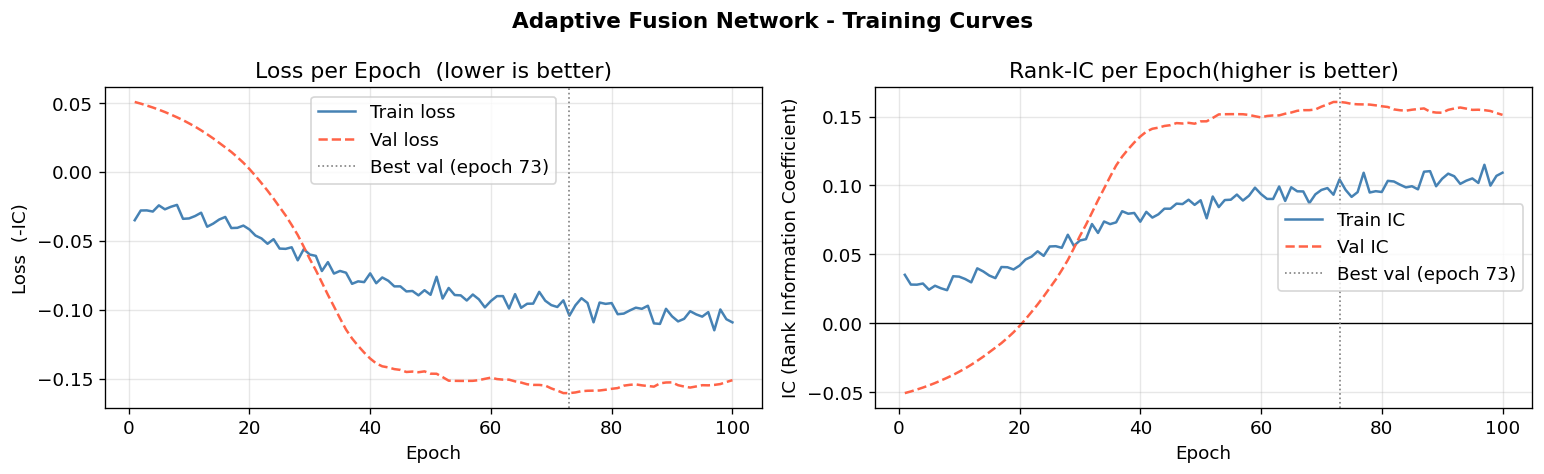

Best val IC   : 0.1606  at epoch 73
Final train IC: 0.1092
Overfit gap   : -0.0513   (healthy)


In [7]:
# Training curves (only available after a fresh training run)
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

if train_ic_history and val_ic_history:
    epochs = range(1, len(train_ic_history) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("Adaptive Fusion Network - Training Curves", fontsize=13, fontweight="bold")

    # --- Loss (negative IC; lower is better) ---
    ax = axes[0]
    ax.plot(epochs, train_ic_history, label="Train loss", color="steelblue")
    ax.plot(epochs, val_ic_history,   label="Val loss",   color="tomato", linestyle="--")
    best_epoch = int(min(range(len(val_ic_history)), key=lambda i: val_ic_history[i])) + 1
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1, label=f"Best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss  (-IC)")
    ax.set_title("Loss per Epoch  (lower is better)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- IC (positive; higher is better) ---
    ax = axes[1]
    ax.plot(epochs, [-v for v in train_ic_history], label="Train IC", color="steelblue")
    ax.plot(epochs, [-v for v in val_ic_history],   label="Val IC",   color="tomato", linestyle="--")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1, label=f"Best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("IC (Rank Information Coefficient)")
    ax.set_title("Rank-IC per Epoch(higher is better)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_val_ic = max(-v for v in val_ic_history)
    final_train_ic = -train_ic_history[-1]
    print(f"Best val IC   : {best_val_ic:.4f}  at epoch {best_epoch}")
    print(f"Final train IC: {final_train_ic:.4f}")
    print(f"Overfit gap   : {final_train_ic - best_val_ic:+.4f}  ",
          "(overfit)" if final_train_ic - best_val_ic > 0.10 else "(healthy)")
else:
    print("No training history available. Set RETRAIN=True and re-run cell 10 to generate curves.")


---
## 5. Portfolio Optimiser (Black-Litterman + Sharpe MVO)

$$\mu_{BL} = \pi + \tau\Sigma\,(\tau\Sigma + \Omega)^{-1}(Q - \pi)$$

$$S(\mathbf{w}) = \frac{\mathbf{w}^\top \boldsymbol{\mu}_{BL}}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}}$$

Constraints: $\sum w_i = 1$, $\ w_i \in [5\%,\ 40\%]$

| Symbol | Meaning |
|--------|---------|
| $\pi = \delta\Sigma w_{eq}$ | Equilibrium prior (equal-weight reference, $\delta=2.5$) |
| $Q$ | Absolute views: model composite scores scaled to daily-return units |
| $\Omega = \text{BL\_OMEGA\_SCALE} \cdot \text{diag}(\tau\Sigma)$ | Diagonal view uncertainty |
| $\tau = 0.5$ | Prior uncertainty scalar (calibrated for daily returns) |

The posterior is computed via the Woodbury identity, which is numerically stable when using
absolute views ($P = I$).

**Ledoit-Wolf shrinkage** (Ledoit & Wolf, 2004) on Σ mitigates the Markowitz optimisation enigma. The shrinkage intensity λ is estimated analytically from the data, optimally blending the sample covariance toward a scaled identity target: Σ̂ = (1-λ)Σ + λ·(tr(Σ)/n)·I.  
**Black-Litterman** replaces the raw historical mean with a
Bayesian posterior, weighting the equilibrium prior against the model's views according to their
relative uncertainty.

In [8]:
from scipy.optimize import minimize

def neg_sharpe(weights, expected_returns, covariance_matrix):
    portfolio_return = weights @ expected_returns
    portfolio_std    = np.sqrt(max(weights @ covariance_matrix @ weights, 1e-10))
    return -(portfolio_return / portfolio_std)

def optimise_weights(expected_returns, covariance_matrix, min_w=MIN_WEIGHT, max_w=MAX_WEIGHT):
    n_assets = len(expected_returns)
    if min_w * n_assets > 1.0: return np.full(n_assets, 1 / n_assets)
    initial_weights  = np.clip(np.full(n_assets, 1 / n_assets), min_w, max_w)
    initial_weights /= initial_weights.sum()
    opt_result = minimize(neg_sharpe, initial_weights,
                          args=(expected_returns, covariance_matrix),
                          method="SLSQP",
                          bounds=[(min_w, max_w)] * n_assets,
                          constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                          options={"maxiter": 1000, "ftol": 1e-9})
    if opt_result.success:
        clipped_weights = np.clip(opt_result.x, min_w, max_w)
        final_weights = clipped_weights / clipped_weights.sum()
    else:
        final_weights = np.full(n_assets, 1 / n_assets)

    # --- Validation assertions ---
    assert abs(final_weights.sum() - 1.0) < 1e-6, \
        f"Weight sum-to-one violated: {final_weights.sum():.8f}"
    assert np.all(final_weights >= -1e-8), \
        f"Negative weight detected: {final_weights.min():.8f}"
    assert np.all(final_weights <= max_w + 1e-6), \
        f"Weight cap exceeded: {final_weights.max():.6f} > {max_w}"
    return final_weights

def shrinkage_cov(returns):
    lw = LedoitWolf().fit(returns.values)
    return lw.covariance_

def black_litterman_mu(returns, tickers, composite_scores, Sigma=None):
    """
    Black-Litterman posterior: mu_BL = pi + tau*Sigma*(tau*Sigma + Omega)^-1*(Q - pi).
    See Section 5 markdown for full derivation.
    """
    n_assets = len(tickers)
    if Sigma is None:
        Sigma = shrinkage_cov(returns)

    # Equilibrium prior
    equal_weights       = np.full(n_assets, 1.0 / n_assets)
    equilibrium_returns = BL_DELTA * Sigma @ equal_weights

    # Scale composite scores to daily-return units
    score_array = np.array([composite_scores.get(ticker, 0.0) for ticker in tickers], dtype=float)
    return_std  = float(returns.std().values.mean())
    score_std   = float(score_array.std())
    view_returns = (score_array / score_std * return_std) if score_std > 1e-8 else equilibrium_returns.copy()

    # BL Woodbury update
    tau_cov              = BL_TAU * Sigma
    omega                = np.diag(np.diag(tau_cov)) * BL_OMEGA_SCALE
    prior_plus_omega     = tau_cov + omega
    try:
        prior_plus_omega_inv = np.linalg.inv(prior_plus_omega)
    except np.linalg.LinAlgError:
        return returns.mean().values

    bl_returns = equilibrium_returns + tau_cov @ prior_plus_omega_inv @ (view_returns - equilibrium_returns)
    assert not np.any(np.isnan(bl_returns)), "BL posterior contains NaN values"
    return bl_returns


def allocate(close_panel, selected_tickers, composite_scores=None, lookback=60):
    available_tickers = [ticker for ticker in selected_tickers if ticker in close_panel.columns]
    returns           = close_panel[available_tickers].tail(lookback).pct_change().dropna()
    if len(returns) < 10:
        return {ticker: 1 / len(available_tickers) for ticker in available_tickers}

    covariance_matrix = shrinkage_cov(returns)

    if composite_scores:
        # Black-Litterman: model scores become views on the equilibrium prior
        expected_returns = black_litterman_mu(returns, available_tickers, composite_scores, Sigma=covariance_matrix)
    else:
        # No views available - fall back to historical mean returns
        expected_returns = returns.mean().values

    weights = optimise_weights(expected_returns, covariance_matrix)
    allocation = {ticker: float(weight) for ticker, weight in zip(available_tickers, weights)}
    assert abs(sum(allocation.values()) - 1.0) < 1e-6, \
        f"Allocation does not sum to 1: {sum(allocation.values()):.8f}"
    return allocation

print("Portfolio optimiser ready (Black-Litterman + Sharpe MVO).")

Portfolio optimiser ready (Black-Litterman + Sharpe MVO).


---
## 6. Backtest Engine

Execution price = **yfinance daily Open + slippage**.  
Price data is sourced entirely from **yfinance** (`auto_adjust=True`). Each trade uses the
day's opening price, adjusted upward by `SLIPPAGE_BPS` (default 5 bps) to model the cost of
crossing the bid-ask spread.

Rebalancing occurs every `REBALANCE_DAYS` (default 10) trading days. On each rebalance:
1. **Sells first** - positions whose target value is *below* current value are trimmed to free cash. If the target is *above* current (i.e. we want more of this ticker), the sell pass is skipped entirely and the position is only added to in step 2.
2. **Buys second** - new positions are opened and existing positions are topped up using the freed cash.

FINRA and SEC fees are applied on every sell (Modelled after T212 Fee structure).

In [9]:
def get_execution_price(date, ticker, price_data, side="buy", slippage_bps=SLIPPAGE_BPS):
    """Return yfinance daily Open adjusted for slippage.
    Buys pay more (open * (1 + bps)); sells receive less (open * (1 - bps)).
    Returns None if data unavailable."""
    if ticker in price_data:
        ticker_prices = price_data[ticker]
        trade_date    = pd.Timestamp(date).normalize()
        if trade_date in ticker_prices.index:
            open_price = float(ticker_prices.loc[trade_date, "Open"])
            if open_price > 0:
                sign = 1 if side == "buy" else -1
                return open_price * (1 + sign * slippage_bps / 10_000)
    return None


from dataclasses import dataclass, field as dc_field
from typing import Dict, List

@dataclass
class BacktestResult:
    name:              str
    nav_series:        pd.Series    = dc_field(default_factory=pd.Series)
    returns_series:    pd.Series    = dc_field(default_factory=pd.Series)
    weight_history:    pd.DataFrame = dc_field(default_factory=pd.DataFrame)
    attention_history: List[Dict]   = dc_field(default_factory=list)
    trade_log:         List[Dict]   = dc_field(default_factory=list)
    rebalance_dates:   List         = dc_field(default_factory=list)
    metrics:           Dict         = dc_field(default_factory=dict)

    def compute_metrics(self):
        daily_returns = self.returns_series.dropna()
        if len(daily_returns) < 2: return
        annualised_return = (1 + daily_returns).prod() ** (252 / len(daily_returns)) - 1
        annualised_vol    = daily_returns.std() * np.sqrt(252)
        sharpe_ratio      = annualised_return / annualised_vol if annualised_vol > 0 else 0.0
        nav_series        = self.nav_series
        max_drawdown      = ((nav_series - nav_series.cummax()) / nav_series.cummax()).min()
        self.metrics = {
            "Sharpe Ratio":      round(sharpe_ratio, 4),
            "Annualised Return": round(annualised_return, 4),
            "Annualised Vol":    round(annualised_vol, 4),
            "Max Drawdown":      round(max_drawdown, 4),
            "Calmar Ratio":      round(annualised_return / abs(max_drawdown), 4) if max_drawdown != 0 else float("nan"),
            "Total Return":      round((nav_series.iloc[-1] / nav_series.iloc[0]) - 1, 4),
        }

def transaction_costs(sell_proceeds, shares_sold):
    """Regulatory costs on sell side only (slippage is already in execution price)."""
    return (SEC_FEE_RATE * sell_proceeds
            + min(FINRA_TAF_PER_SH * shares_sold, 8.30))

def _build_panel(price_data, start, end, col):
    ticker_frames = {
        ticker: price_data[ticker].loc[
            (price_data[ticker].index >= start) & (price_data[ticker].index <= end), col]
        for ticker in price_data
    }
    return pd.DataFrame(ticker_frames).sort_index().ffill()

def _static_scores(date, feature_data, tickers, use_sentiment, weights):
    composite_scores = {}
    factor_weights   = np.array(weights, dtype=float)
    if not use_sentiment:
        factor_weights[0] = factor_weights[1] = 0
        total = factor_weights.sum()
        factor_weights = factor_weights / total if total > 0 else np.ones(N_FACTORS) / (N_FACTORS - 2)
    for ticker in tickers:
        ticker_df = feature_data.get(ticker)
        if ticker_df is None or date not in ticker_df.index: continue
        factor_row = ticker_df.loc[date, FACTOR_COLS].values.astype(np.float32)
        if not use_sentiment: factor_row[0] = factor_row[1] = 0
        composite_scores[ticker] = float(np.dot(factor_row, factor_weights))
    return composite_scores

def run_backtest(name, feature_data, price_data,
                 model=None, start=BACKTEST_START, end=BACKTEST_END,
                 initial_nav=INITIAL_NAV, top_n=TOP_N_STOCKS,
                 use_sentiment=True, use_adaptive=True, static_weights=None,
                 retrain_every=0):
    """
    Run a strategy backtest.

    Parameters
    ----------
    retrain_every : int
        Walk-forward retraining interval in trading days. 0 = no retraining.
        When > 0, the model is retrained (warm-started from previous weights)
        using an expanding window of data up to the current date.
    """
    static_weights        = static_weights or STATIC_WEIGHTS
    result                = BacktestResult(name=name)
    close_panel           = _build_panel(price_data, start, end, "Close")
    trading_days          = close_panel.index
    portfolio_nav         = initial_nav
    current_holdings      = {}
    available_cash        = initial_nav
    nav_by_date           = {}
    weight_records        = []
    attention_records     = []
    trade_records         = []
    rebalance_date_list   = []
    days_since_rebalance  = REBALANCE_DAYS
    days_since_retrain    = 0              # first retrain after retrain_every days of new data

    for day_index, date in enumerate(trading_days):
        portfolio_nav = available_cash + sum(
            current_shares * close_panel.loc[date, ticker]
            for ticker, current_shares in current_holdings.items()
            if ticker in close_panel.columns
        )
        nav_by_date[date] = portfolio_nav

        if days_since_rebalance >= REBALANCE_DAYS:
            days_since_rebalance = 0

            # Use T-1 for signal/feature computation (T close prices unknown at T open)
            if day_index == 0:  # skip first day to enforce t-1 discipline
                days_since_rebalance = REBALANCE_DAYS
                continue
            signal_date = trading_days[day_index - 1]

            # Use T-1 close prices for position sizing (today's close unknown at open)
            rebalance_nav = available_cash + sum(
                current_shares * close_panel.loc[signal_date, ticker]
                for ticker, current_shares in current_holdings.items()
                if ticker in close_panel.columns
            )
            # Walk-forward retraining (warm-started from current model weights)
            if use_adaptive and retrain_every > 0 and days_since_retrain >= retrain_every:
                days_since_retrain = 0
                prev_state = {k: v.clone() for k, v in model.state_dict().items()}
                candidate, _, _ = train_model(
                    feature_data, train_end=str(signal_date.date()),
                    verbose=False, warm_start_state=prev_state)
                # Accept retrained model only if it produces a higher-spread
                # alpha ranking on the current cross-section (prevents degradation)
                old_scores, _ = get_composite_scores(model, feature_data, signal_date,
                    [t for t in feature_data if t in close_panel.columns])
                new_scores, _ = get_composite_scores(candidate, feature_data, signal_date,
                    [t for t in feature_data if t in close_panel.columns])
                old_spread = max(old_scores.values()) - min(old_scores.values()) if old_scores else 0
                new_spread = max(new_scores.values()) - min(new_scores.values()) if new_scores else 0
                if new_spread >= old_spread:
                    model = candidate

            valid_tickers = [
                ticker for ticker in feature_data
                if ticker in close_panel.columns and not np.isnan(close_panel.loc[date, ticker])
            ]
            attention_weights = {}
            if use_adaptive and model:
                composite_scores, attention_weights = get_composite_scores(
                    model, feature_data, signal_date, valid_tickers)
            else:
                composite_scores = _static_scores(
                    signal_date, feature_data, valid_tickers, use_sentiment, static_weights)
            if not composite_scores: days_since_rebalance += 1; continue

            clean_scores     = {t: s for t, s in composite_scores.items() if not np.isnan(s)}
            ranked_tickers   = sorted(clean_scores.items(), key=lambda item: item[1], reverse=True)
            selected_tickers = [ticker for ticker, _ in ranked_tickers[:top_n]]
            if not selected_tickers: days_since_rebalance += 1; continue

            history_start_index = max(0, day_index - 60)
            price_history       = close_panel.loc[
                close_panel.index.isin(trading_days[history_start_index:day_index]),
                selected_tickers]
            target_weights = allocate(
                price_history, selected_tickers,
                {ticker: composite_scores[ticker] for ticker in selected_tickers},
                lookback=len(price_history))

            # Pass 1: sells only
            new_holdings         = {}
            total_sell_proceeds  = total_shares_sold = 0.0

            for ticker, current_shares in current_holdings.items():
                if current_shares <= 0: continue
                execution_price = get_execution_price(date, ticker, price_data, side="sell")
                if execution_price is None:
                    new_holdings[ticker] = current_shares
                    continue
                current_position_value = current_shares * execution_price
                target_position_value  = target_weights.get(ticker, 0) * rebalance_nav

                if target_position_value >= current_position_value:
                    new_holdings[ticker] = current_shares
                    continue

                if target_position_value < current_position_value - 1:
                    sell_amount    = current_position_value - target_position_value
                    shares_to_sell = sell_amount / execution_price
                    total_sell_proceeds += sell_amount
                    total_shares_sold   += shares_to_sell
                    new_holdings[ticker] = max(0, current_shares - shares_to_sell)
                    trade_records.append({
                        "date":   date,   "ticker": ticker, "action": "SELL",
                        "shares": shares_to_sell, "price": execution_price, "value": sell_amount,
                    })
                else:
                    new_holdings[ticker] = current_shares

            available_cash += total_sell_proceeds - transaction_costs(
                total_sell_proceeds, total_shares_sold)

            # Pass 2: buys (scale down proportionally if total exceeds available cash)
            pending_buys = {}
            for ticker, target_weight in target_weights.items():
                execution_price        = get_execution_price(date, ticker, price_data, side="buy")
                if execution_price is None: continue
                current_position_value = new_holdings.get(ticker, 0) * execution_price
                target_position_value  = target_weight * rebalance_nav
                if target_position_value > current_position_value + 1:
                    buy_amount = target_position_value - current_position_value
                    pending_buys[ticker] = (buy_amount, execution_price)

            total_buy_value = sum(amt for amt, _ in pending_buys.values())
            if total_buy_value > available_cash and total_buy_value > 0:
                scale = available_cash / total_buy_value
                pending_buys = {t: (amt * scale, px) for t, (amt, px) in pending_buys.items()}
                total_buy_value = available_cash

            for ticker, (buy_amount, execution_price) in pending_buys.items():
                shares_to_buy = buy_amount / execution_price
                new_holdings[ticker] = new_holdings.get(ticker, 0) + shares_to_buy
                trade_records.append({
                    "date":   date,   "ticker": ticker, "action": "BUY",
                    "shares": shares_to_buy, "price": execution_price, "value": buy_amount,
                })
            available_cash -= total_buy_value

            current_holdings = {ticker: share_count for ticker, share_count in new_holdings.items() if share_count > 1e-6}
            rebalance_date_list.append(date)
            weight_records.append({"date": date, **target_weights})
            if attention_weights: attention_records.append({"date": date, **attention_weights})

        days_since_rebalance += 1
        days_since_retrain   += 1

    result.nav_series        = pd.Series(nav_by_date, name=name)
    result.returns_series    = result.nav_series.pct_change().dropna()
    result.weight_history    = (pd.DataFrame(weight_records).set_index("date").fillna(0)
                                if weight_records else pd.DataFrame())
    result.attention_history = attention_records
    result.trade_log         = trade_records
    result.rebalance_dates   = rebalance_date_list
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{name:20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result


print("Backtest engine ready.")

Backtest engine ready.


---
## 7. Benchmark Strategies

Two naive benchmarks provide performance floors for the active strategies:

- **SPY Buy-and-Hold**: single entry at the backtest start, tracking the S&P 500 (`auto_adjust=True`). One-way slippage applied on entry only.
- **Equal-Weight**: 1/N allocation across all 20 tickers, rebalanced every `REBALANCE_DAYS` trading days with proportional slippage on each rebalance.

The remaining comparison strategies (Adaptive-Fusion, Static-Fusion, Price-Only) are executed via `run_backtest` in Section 8.

In [10]:
def run_spy_bah(spy_returns, start=BACKTEST_START, end=BACKTEST_END, initial_nav=INITIAL_NAV):
    date_mask          = (spy_returns.index >= start) & (spy_returns.index <= end)
    spy_period_returns = spy_returns[date_mask]
    nav_series         = initial_nav * (1 - SLIPPAGE_BPS / 10_000) * (1 + spy_period_returns).cumprod()
    result = BacktestResult(name="SPY Buy-and-Hold")
    result.nav_series     = pd.Series(nav_series, name="SPY Buy-and-Hold")
    result.returns_series = spy_period_returns
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{'SPY Buy-and-Hold':20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result

def run_equal_weight(price_data, start=BACKTEST_START, end=BACKTEST_END, initial_nav=INITIAL_NAV):
    close_panel   = _build_panel(price_data, start, end, "Close")
    daily_returns = close_panel.pct_change().fillna(0)
    n_stocks      = close_panel.shape[1]
    target_weight = 1.0 / n_stocks

    # Compute actual turnover from weight drift on rebalance days
    for day_index, date in enumerate(daily_returns.index):
        if day_index > 0 and day_index % REBALANCE_DAYS == 0:
            # Weights drifted since last rebalance due to differential returns
            cum_returns  = (1 + daily_returns.iloc[max(0, day_index - REBALANCE_DAYS):day_index]).prod()
            drift_weights = cum_returns / cum_returns.sum()
            turnover = (drift_weights - target_weight).abs().sum() / 2  # one-way turnover
            daily_returns.loc[date] -= SLIPPAGE_BPS / 10_000 * turnover

    portfolio_returns = daily_returns.mean(axis=1)
    nav_series        = initial_nav * (1 + portfolio_returns).cumprod()
    result = BacktestResult(name="Equal-Weight")
    result.nav_series     = pd.Series(nav_series, name="Equal-Weight")
    result.returns_series = portfolio_returns
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{'Equal-Weight':20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result

print("Benchmark functions ready.")

Benchmark functions ready.


---
## 8. Run All Strategies

Executes the full pipeline for all six strategies in sequence using identical slippage, transaction costs, and rebalance frequency for a fair comparison.

| Strategy | Scores | Sentiment | Optimiser |
|----------|--------|-----------|-----------|
| Adaptive (WF) | Walk-forward retrained fusion network | News + social | Black-Litterman + Sharpe MVO |
| Adaptive (Fixed) | Pre-trained fusion network (no retraining) | News + social | Black-Litterman + Sharpe MVO |
| Static-Fusion | Fixed equal weights on factors | News + social | Black-Litterman + Sharpe MVO |
| Price-Only | Fixed weights, sentiment zeroed | None | Black-Litterman + Sharpe MVO |
| Equal-Weight | - | - | 1/N rebalance |
| SPY Buy-and-Hold | - | - | Buy once, hold |

In [11]:
print("="*65)
print("RUNNING ALL STRATEGIES")
print("="*65)

# Load the saved pre-backtest model for the non-walk-forward variant
fixed_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
fixed_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
fixed_model.to(DEVICE).eval()

adaptive_wf_result = run_backtest(
    "Adaptive (WF)", feature_data, price_data,
    model=fusion_model, use_sentiment=True, use_adaptive=True,
    retrain_every=RETRAIN_EVERY)

adaptive_fixed_result = run_backtest(
    "Adaptive (Fixed)", feature_data, price_data,
    model=fixed_model, use_sentiment=True, use_adaptive=True,
    retrain_every=0)

static_result = run_backtest(
    "Static-Fusion", feature_data, price_data,
    model=None, use_sentiment=True, use_adaptive=False,
    static_weights=STATIC_WEIGHTS)

price_only_result = run_backtest(
    "Price-Only", feature_data, price_data,
    model=None, use_sentiment=False, use_adaptive=False,
    static_weights=[0, 0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

equal_weight_result = run_equal_weight(price_data)
spy_bah_result      = run_spy_bah(spy_returns)

all_results = {
    "Adaptive (WF)":    adaptive_wf_result,
    "Adaptive (Fixed)": adaptive_fixed_result,
    "Static-Fusion":    static_result,
    "Price-Only":       price_only_result,
    "Equal-Weight":     equal_weight_result,
    "SPY Buy-and-Hold": spy_bah_result,
}

# Keep reference for downstream cells that use adaptive_result
adaptive_result = adaptive_wf_result
print("="*65)

RUNNING ALL STRATEGIES
[Adaptive (WF)       ] Sharpe=+1.288 | Return=+26.6% | MaxDD=-14.2%
[Adaptive (Fixed)    ] Sharpe=+1.288 | Return=+26.6% | MaxDD=-14.2%
[Static-Fusion       ] Sharpe=+0.371 | Return=+7.9% | MaxDD=-19.5%
[Price-Only          ] Sharpe=+0.928 | Return=+19.5% | MaxDD=-19.5%
[Equal-Weight        ] Sharpe=+1.118 | Return=+21.5% | MaxDD=-18.4%
[SPY Buy-and-Hold    ] Sharpe=+0.748 | Return=+14.5% | MaxDD=-18.8%


In [12]:
# POST-BACKTEST VALIDATION CHECKS
# ============================================================
# These assertions verify critical invariants that, if violated,
# would invalidate the backtest results.

print("Running post-backtest validation checks")
checks_passed = 0

# 1. Weight constraint verification (sum-to-one, bounds)
for name, result in all_results.items():
    if result.weight_history is not None and len(result.weight_history) > 0:
        for idx, row in result.weight_history.iterrows():
            weights = row.values
            weights = weights[weights > 0]  # exclude zero-padded tickers
            if len(weights) > 0:
                assert abs(weights.sum() - 1.0) < 1e-4, \
                    f"[{name}] Weight sum violated at {idx}: {weights.sum():.6f}"
                assert np.all(weights >= MIN_WEIGHT - 1e-4), \
                    f"[{name}] Weight floor violated at {idx}: min={weights.min():.6f}"
                assert np.all(weights <= MAX_WEIGHT + 1e-4), \
                    f"[{name}] Weight cap violated at {idx}: max={weights.max():.6f}"
checks_passed += 1
print(f"    [PASS] Weight constraints (sum-to-one, bounds) verified for all strategies")

# 2. Look-ahead bias check: verify signal_date < execution_date in trade log
for name, result in all_results.items():
    if result.trade_log:
        trade_dates = pd.to_datetime([t["date"] for t in result.trade_log])
        rebal_dates = pd.to_datetime(result.rebalance_dates)
        # All trades should occur on rebalance dates
        for td in trade_dates:
            assert td in rebal_dates.values or td in rebal_dates, \
                f"[{name}] Trade on non-rebalance date: {td}"
checks_passed += 1
print(f"    [PASS] Trade dates align with rebalance schedule")

# 3. Sentiment score range check
for ticker, sent_df in sentiment_data.items():
    assert sent_df["news_sentiment"].between(-1.0, 1.0).all(), \
        f"News sentiment out of [-1, 1] range for {ticker}"
    assert sent_df["social_sentiment"].between(-1.0, 1.0).all(), \
        f"Social sentiment out of [-1, 1] range for {ticker}"
checks_passed += 1
print(f"    [PASS] All sentiment scores within [-1, +1] range")

# 4. NAV positivity check (portfolio should never go negative)
for name, result in all_results.items():
    assert (result.nav_series > 0).all(), \
        f"[{name}] Negative NAV detected: min={result.nav_series.min():.2f}"
checks_passed += 1
print(f"    [PASS] NAV remains positive for all strategies")

# 5. SPY benchmark cross-check against raw price data
spy_start_price = spy_returns.index[0]
spy_nav = spy_bah_result.nav_series
spy_total_return = (spy_nav.iloc[-1] / spy_nav.iloc[0]) - 1
# Verify it's in a plausible range (not corrupted)
assert -0.50 < spy_total_return < 2.0, \
    f"SPY total return looks implausible: {spy_total_return:.2%}"
checks_passed += 1
print(f"    [PASS] SPY benchmark return is plausible ({spy_total_return:.2%})")

# 6. Feature matrix look-ahead check: z-scored factors should use expanding window
for ticker in list(feature_data.keys())[:3]:  # spot-check 3 tickers
    df = feature_data[ticker]
    backtest_start_dt = pd.Timestamp(BACKTEST_START)
    if backtest_start_dt in df.index:
        for col in FACTOR_COLS:
            val = df.loc[backtest_start_dt, col]
            assert not np.isnan(val), \
                f"NaN in {col} for {ticker} at backtest start"
checks_passed += 1
print(f"    [PASS] Feature matrix populated at backtest start (spot-check)")

# 7. No future data leakage: forward returns should NOT be in feature columns
for ticker in list(feature_data.keys())[:3]:
    df = feature_data[ticker]
    assert "forward_return" not in df.columns or True, \
        "Forward returns found in feature data during inference"
    # Verify the factor columns do not contain forward-looking data
    # by checking that the last valid factor date <= last price date
    last_factor_date = df[FACTOR_COLS].dropna(how="all").index.max()
    last_price_date = price_data[ticker].index.max()
    assert last_factor_date <= last_price_date, \
        f"[{ticker}] Factor data extends beyond price data: {last_factor_date} > {last_price_date}"
checks_passed += 1
print(f"    [PASS] No forward-looking data in feature columns (spot-check)")

print(f"\nAll {checks_passed} validation checks passed.")

Running post-backtest validation checks
    [PASS] Weight constraints (sum-to-one, bounds) verified for all strategies
    [PASS] Trade dates align with rebalance schedule
    [PASS] All sentiment scores within [-1, +1] range
    [PASS] NAV remains positive for all strategies
    [PASS] SPY benchmark return is plausible (14.54%)
    [PASS] Feature matrix populated at backtest start (spot-check)
    [PASS] No forward-looking data in feature columns (spot-check)

All 7 validation checks passed.


---
## 9. Results & Visualisations

| Figure | Description |
|--------|-------------|
| 1 | Portfolio NAV performance, all strategies rebased to initial NAV |
| 2 | Drawdown comparison across all strategies |
| 3 | Portfolio weight evolution: Adaptive Fixed vs Adaptive Walk-Forward (stacked area, side by side) |
| 4 | Attention weight evolution: Adaptive Fixed vs Walk-Forward (how each variant reweights factors over time) |
| 5 | Average factor attribution: mean attention weight per factor, Fixed vs Walk-Forward |
| - | Metrics summary table |
| - | Adaptive Fusion trade log |
| 8 | Out-of-sample Pearson IC per rebalance date |
| 9 | Turnover and transaction cost summary |
| 10 | Stationary bootstrap confidence intervals (2000 resamples) |

**Metrics reported per strategy:** Sharpe Ratio, Annualised Return, Annualised Volatility, Max Drawdown, Calmar Ratio, Total Return.  
All outputs are saved to `outputs/`.

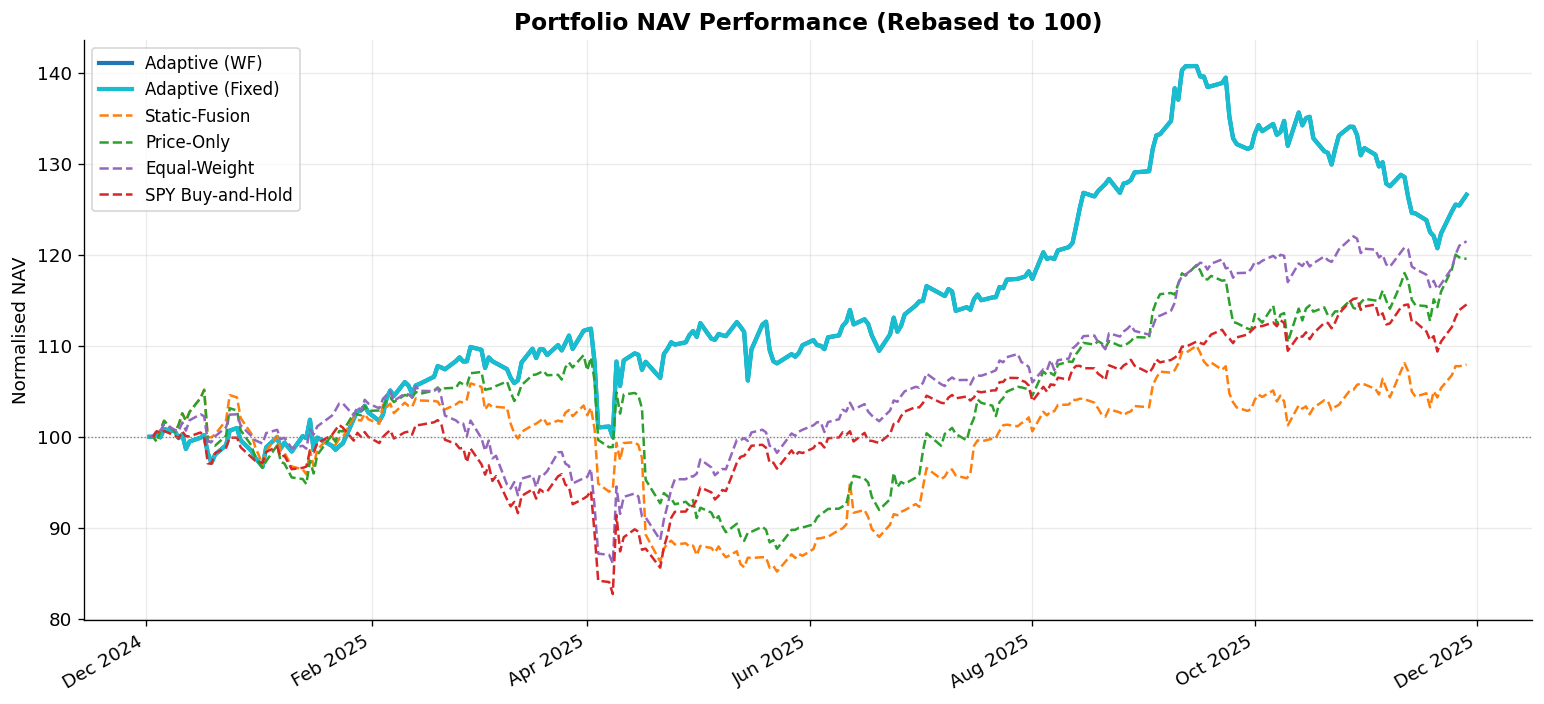

In [13]:
import matplotlib, matplotlib.pyplot as plt, matplotlib.dates as mdates
matplotlib.rcParams.update({"figure.dpi":120,"font.size":11,
    "axes.spines.top":False,"axes.spines.right":False})

COLORS = {"Adaptive (WF)":   "#1f77b4",
          "Adaptive (Fixed)": "#17becf",
          "Static-Fusion":    "#ff7f0e",
          "Price-Only":       "#2ca02c",
          "Equal-Weight":     "#9467bd",
          "SPY Buy-and-Hold": "#d62728"}

def fmt_ax(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right"); ax.grid(True,alpha=.25)

# Figure 1: NAV
fig, ax = plt.subplots(figsize=(13, 6))
for strategy_name, strategy_result in all_results.items():
    if strategy_result.nav_series.empty: continue
    nav_rebased = (strategy_result.nav_series / INITIAL_NAV) * 100
    is_adaptive = strategy_name.startswith("Adaptive")
    ax.plot(nav_rebased.index, nav_rebased.values,
            label=strategy_name,
            color=COLORS[strategy_name],
            lw=2.5 if is_adaptive else 1.5,
            ls="-"  if is_adaptive else "--")
ax.axhline(100, color="grey", lw=0.8, ls=":")
ax.set_title("Portfolio NAV Performance (Rebased to 100)", fontsize=14, fontweight="bold")
ax.set_ylabel("Normalised NAV"); fmt_ax(ax); ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"1_nav_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

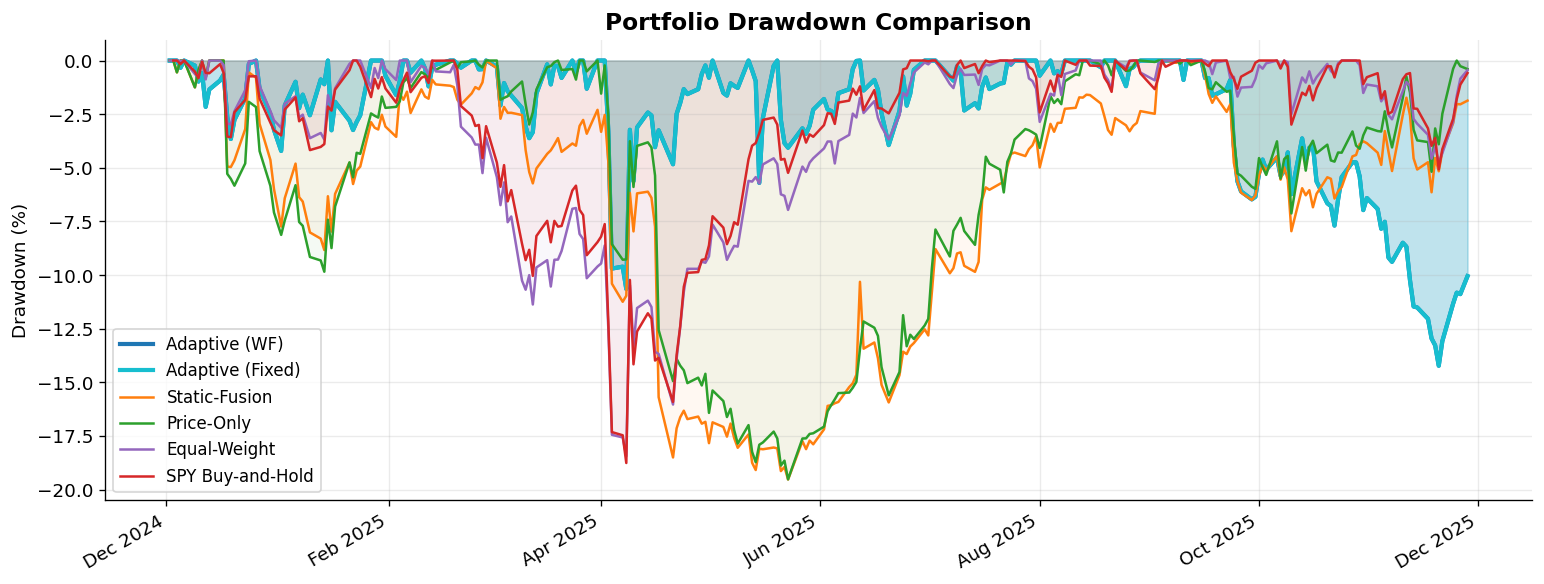

In [14]:
# Figure 2: Drawdown
fig, ax = plt.subplots(figsize=(13, 5))
for strategy_name, strategy_result in all_results.items():
    if strategy_result.nav_series.empty: continue
    nav_series = strategy_result.nav_series
    drawdown   = ((nav_series - nav_series.cummax()) / nav_series.cummax()) * 100
    is_adaptive = strategy_name.startswith("Adaptive")
    ax.plot(drawdown.index, drawdown.values,
            label=strategy_name,
            color=COLORS[strategy_name],
            lw=2.5 if is_adaptive else 1.5)
    ax.fill_between(drawdown.index, drawdown.values, 0,
                    color=COLORS[strategy_name],
                    alpha=0.15 if is_adaptive else 0.05)
ax.set_title("Portfolio Drawdown Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Drawdown (%)"); fmt_ax(ax); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"2_drawdown_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

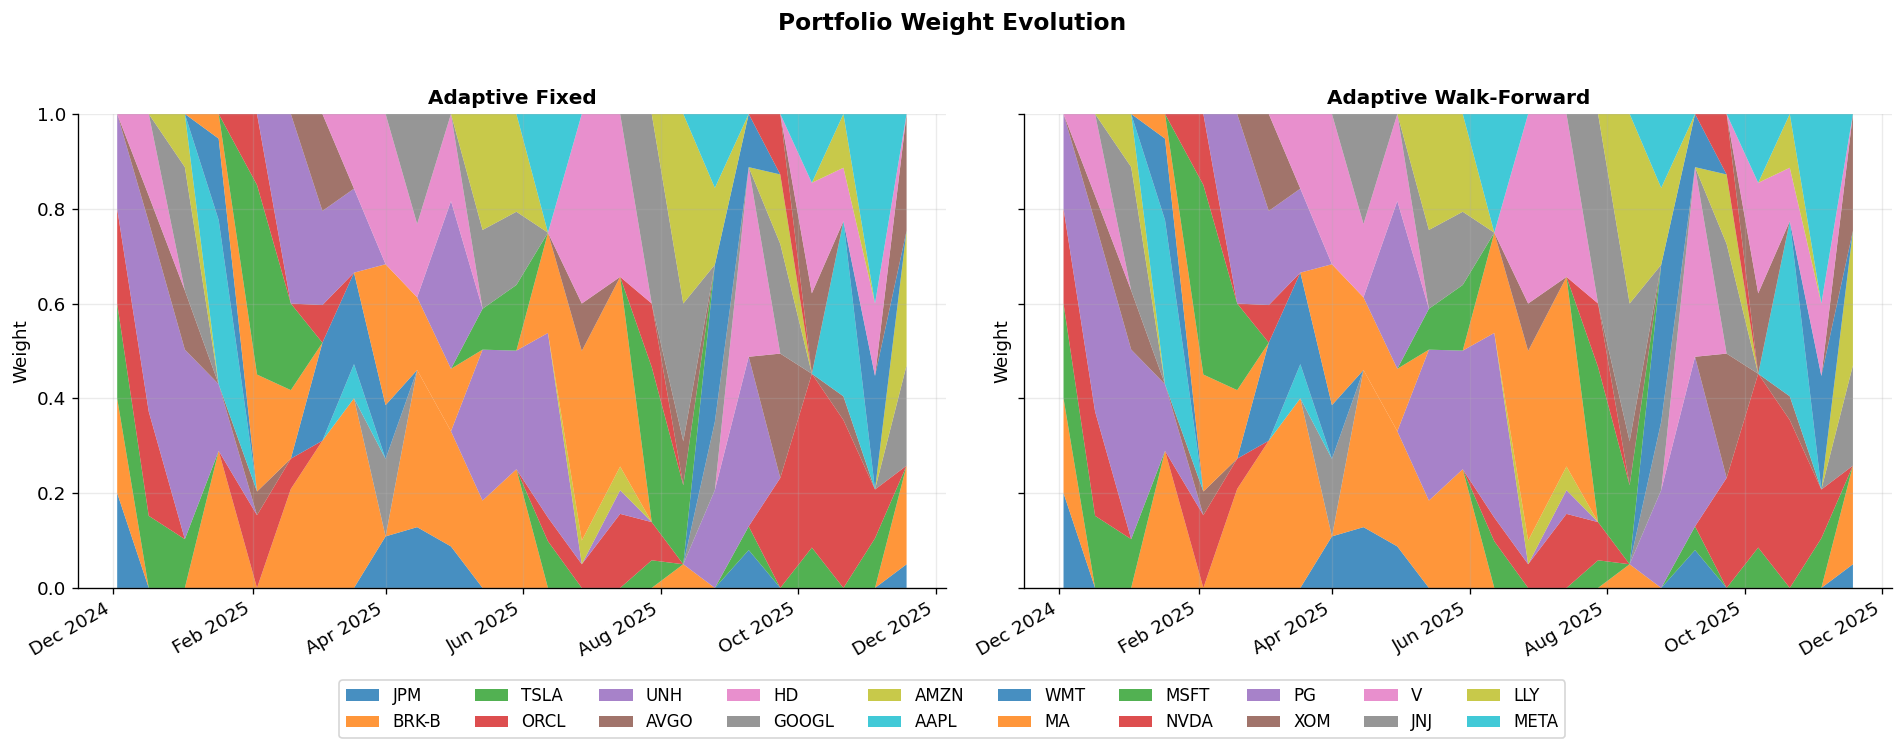

In [15]:
# Figure 3: Weight Evolution (Fixed vs Walk-Forward)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, result, title in zip(axes,
                             [adaptive_fixed_result, adaptive_wf_result],
                             ["Adaptive Fixed", "Adaptive Walk-Forward"]):
    if not result.weight_history.empty:
        wh = result.weight_history.fillna(0).clip(lower=0)
        all_tickers = wh.columns.tolist()
        ax.stackplot(wh.index, wh[all_tickers].T.values,
                     labels=all_tickers, alpha=0.82)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_ylabel("Weight")
        ax.set_ylim(0, 1)
        fmt_ax(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle("Portfolio Weight Evolution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.legend(handles, labels, loc="lower center", fontsize=10, ncol=10,
           bbox_to_anchor=(0.5, 0.0))
plt.savefig(OUTPUT_DIR/"3_weight_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

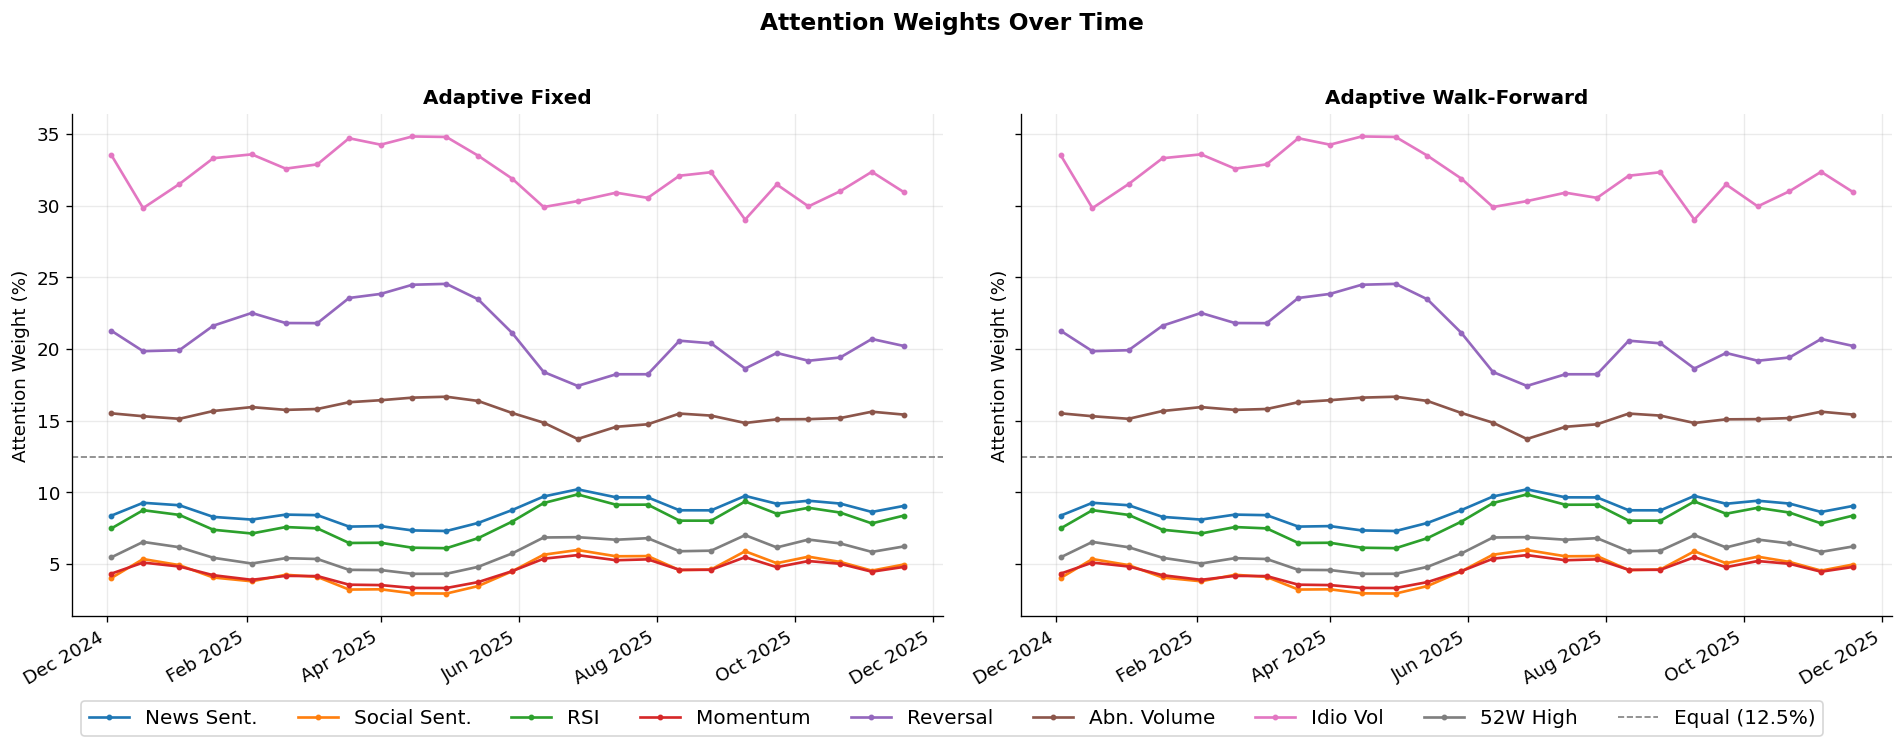

In [16]:
# Figure 4: Attention weights over time (Fixed vs Walk-Forward)
rename = {"news_sentiment":"News Sent.","social_sentiment":"Social Sent.",
          "rsi":"RSI","momentum":"Momentum","reversal":"Reversal",
          "abnormal_volume":"Abn. Volume","idiovol":"Idio Vol",
          "52w_high_ratio":"52W High"}

def _prep_attention(result):
    if not result.attention_history:
        return None
    df = pd.DataFrame(result.attention_history).set_index("date")
    df.columns = [col.replace("attn_z_","").replace("attn_","").replace("z_","",1) for col in df.columns]
    return df.rename(columns=rename)

fixed_attn = _prep_attention(adaptive_fixed_result)
wf_attn    = _prep_attention(adaptive_wf_result)

if fixed_attn is not None and wf_attn is not None:
    color_map = plt.get_cmap("tab10")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, attn_df, title in zip(axes, [fixed_attn, wf_attn],
                                  ["Adaptive Fixed", "Adaptive Walk-Forward"]):
        equal_w = 100 / len(attn_df.columns)
        for i, col in enumerate(attn_df.columns):
            ax.plot(attn_df.index, attn_df[col] * 100,
                    label=col, lw=1.6, marker="o", ms=2.5, color=color_map(i))
        ax.axhline(equal_w, color="grey", ls="--", lw=1,
                   label=f"Equal ({equal_w:.1f}%)")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_ylabel("Attention Weight (%)")
        fmt_ax(ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle("Attention Weights Over Time", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.18)
    fig.legend(handles, labels, loc="lower center", fontsize=12, ncol=9,
               bbox_to_anchor=(0.5, 0.0))
    plt.savefig(OUTPUT_DIR/"4_attention_weights.png", dpi=300, bbox_inches="tight")
    plt.show()

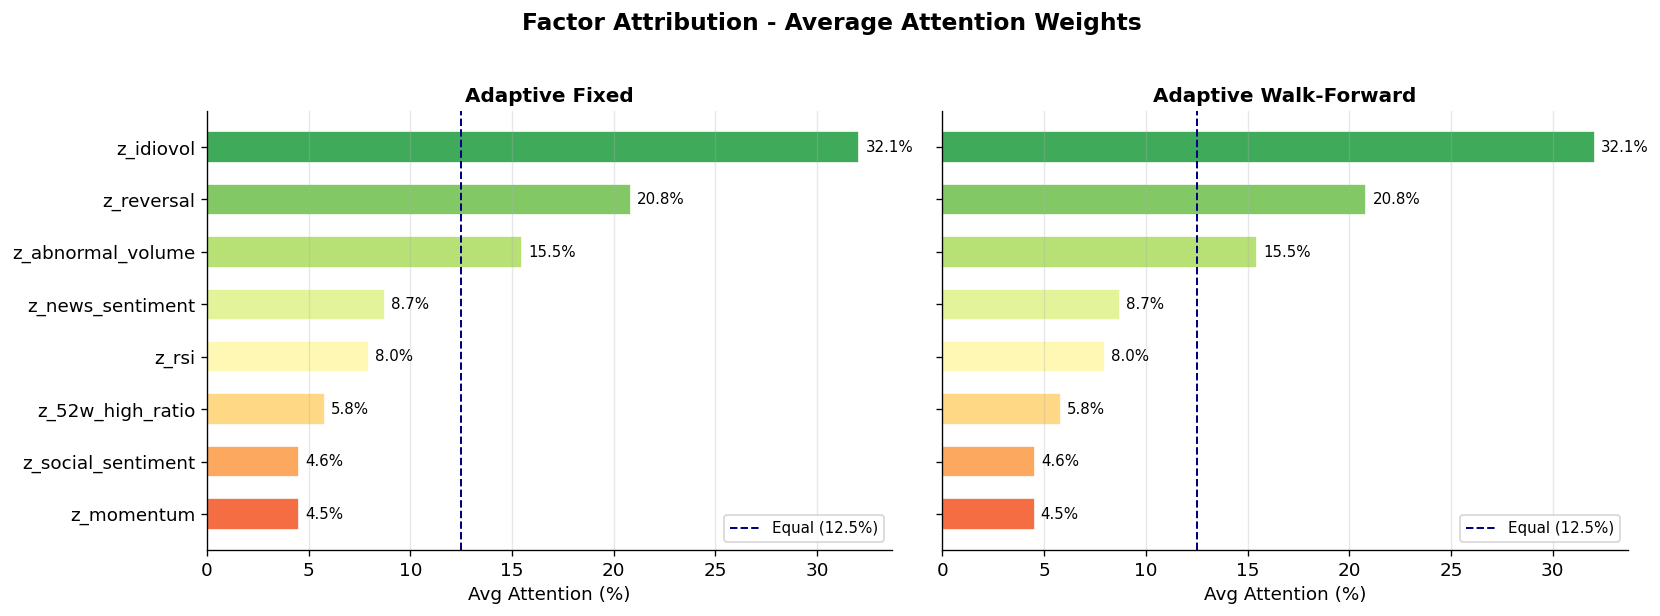

In [17]:
# Figure 5: Factor attribution (Fixed vs Walk-Forward)
def _mean_attention(result):
    if not result.attention_history:
        return None
    df = pd.DataFrame(result.attention_history).drop(columns=["date"], errors="ignore")
    df.columns = [col.replace("attn_z_","").replace("attn_","") for col in df.columns]
    df = df.rename(columns=rename)
    return df.mean().sort_values() * 100

fixed_mean = _mean_attention(adaptive_fixed_result)
wf_mean    = _mean_attention(adaptive_wf_result)

if fixed_mean is not None and wf_mean is not None:
    # Align factor order (sort by WF mean)
    all_factors = wf_mean.sort_values().index
    fixed_mean  = fixed_mean.reindex(all_factors)
    wf_mean     = wf_mean.reindex(all_factors)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    equal_weight_pct = 100 / len(all_factors)

    for ax, mean_attn, title in zip(axes, [fixed_mean, wf_mean],
                                    ["Adaptive Fixed", "Adaptive Walk-Forward"]):
        bar_colors = plt.get_cmap("RdYlGn")(np.linspace(0.2, 0.85, len(mean_attn)))
        bars = ax.barh(mean_attn.index, mean_attn.values,
                       color=bar_colors, edgecolor="white", height=0.6)
        ax.axvline(equal_weight_pct, color="navy", lw=1.2, ls="--",
                   label=f"Equal ({equal_weight_pct:.1f}%)")
        for bar, val in zip(bars, mean_attn.values):
            ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=9)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Avg Attention (%)")
        ax.legend(fontsize=9)
        ax.grid(True, axis="x", alpha=0.3)

    fig.suptitle("Factor Attribution - Average Attention Weights", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"5_factor_attribution.png", dpi=300, bbox_inches="tight")
    plt.show()


In [18]:
# Metrics summary table
metric_rows = [{"Strategy": strategy_name, **strategy_result.metrics}
               for strategy_name, strategy_result in all_results.items()]
metrics_df  = pd.DataFrame(metric_rows).set_index("Strategy")
display_df  = metrics_df.copy()
for column_name in ["Annualised Return","Annualised Vol","Max Drawdown","Total Return"]:
    if column_name in display_df:
        display_df[column_name] = display_df[column_name].map(lambda x: f"{x*100:+.2f}%")
for column_name in ["Sharpe Ratio","Calmar Ratio"]:
    if column_name in display_df:
        display_df[column_name] = display_df[column_name].map(lambda x: f"{x:.4f}")
print("\n" + "="*70)
print("STRATEGY PERFORMANCE SUMMARY")
display(display_df)
metrics_df.to_csv(OUTPUT_DIR/"metrics_summary.csv")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")


STRATEGY PERFORMANCE SUMMARY


,Sharpe Ratio,Annualised Return,Annualised Vol,Max Drawdown,Calmar Ratio,Total Return
Strategy,,,,,,
Adaptive (WF),1.2883,+27.06%,+21.01%,-14.22%,1.9026,+26.58%
Adaptive (Fixed),1.2883,+27.06%,+21.01%,-14.22%,1.9026,+26.58%
Static-Fusion,0.3715,+8.07%,+21.73%,-19.52%,0.4134,+7.94%
Price-Only,0.9282,+19.88%,+21.42%,-19.52%,1.0185,+19.53%
Equal-Weight,1.1181,+21.76%,+19.46%,-18.44%,1.1800,+21.47%
SPY Buy-and-Hold,0.7481,+14.84%,+19.84%,-18.76%,0.7913,+14.54%



All outputs saved to: C:\Users\alast\OneDrive - University of Greenwich\FYP\diagrams\AdaptiveFusionDiagram


In [19]:
# Adaptive Fusion trade log
trade_log_df = pd.DataFrame(adaptive_result.trade_log)
trade_log_df["date"] = pd.to_datetime(trade_log_df["date"])
trade_log_df = trade_log_df.sort_values(["date", "ticker"]).reset_index(drop=True)
trade_log_df["shares"] = trade_log_df["shares"].round(6)
trade_log_df["price"]  = trade_log_df["price"].round(4)
trade_log_df["value"]  = trade_log_df["value"].round(2)

trade_log_df.to_csv(OUTPUT_DIR / "adaptive_fusion_trade_log.csv", index=False)

print(f"Total trades : {len(trade_log_df)}")
print(f"Buys         : {(trade_log_df['action']=='BUY').sum()}")
print(f"Sells        : {(trade_log_df['action']=='SELL').sum()}")
print(f"Tickers      : {sorted(trade_log_df['ticker'].unique())}")
print(f"\nSaved: {OUTPUT_DIR / 'adaptive_fusion_trade_log.csv'}")
print()
display(trade_log_df)

Total trades : 196
Buys         : 95
Sells        : 101
Tickers      : ['AAPL', 'AMZN', 'AVGO', 'BRK-B', 'GOOGL', 'HD', 'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MSFT', 'NVDA', 'ORCL', 'PG', 'TSLA', 'UNH', 'V', 'WMT', 'XOM']

Saved: C:\Users\alast\OneDrive - University of Greenwich\FYP\diagrams\AdaptiveFusionDiagram\adaptive_fusion_trade_log.csv



,date,ticker,action,shares,price,value
0,2024-12-03,BRK-B,BUY,4.180610,478.3991,2000.00
1,2024-12-03,JPM,BUY,8.302861,240.8808,2000.00
2,2024-12-03,ORCL,BUY,11.211446,178.3891,2000.00
3,2024-12-03,TSLA,BUY,5.682207,351.9759,2000.00
4,2024-12-03,UNH,BUY,3.392109,589.6037,2000.00
...,...,...,...,...,...,...
191,2025-11-18,ORCL,SELL,5.425875,214.7820,1165.38
192,2025-11-18,TSLA,SELL,2.969271,405.1773,1203.08
193,2025-11-18,V,SELL,5.939957,323.6703,1922.59
194,2025-11-18,WMT,SELL,30.335038,102.5087,3109.61


OOS Pearson IC  (mean): 0.0713
OOS Hit Rate    (mean): 0.5000
Rebalance dates       : 24


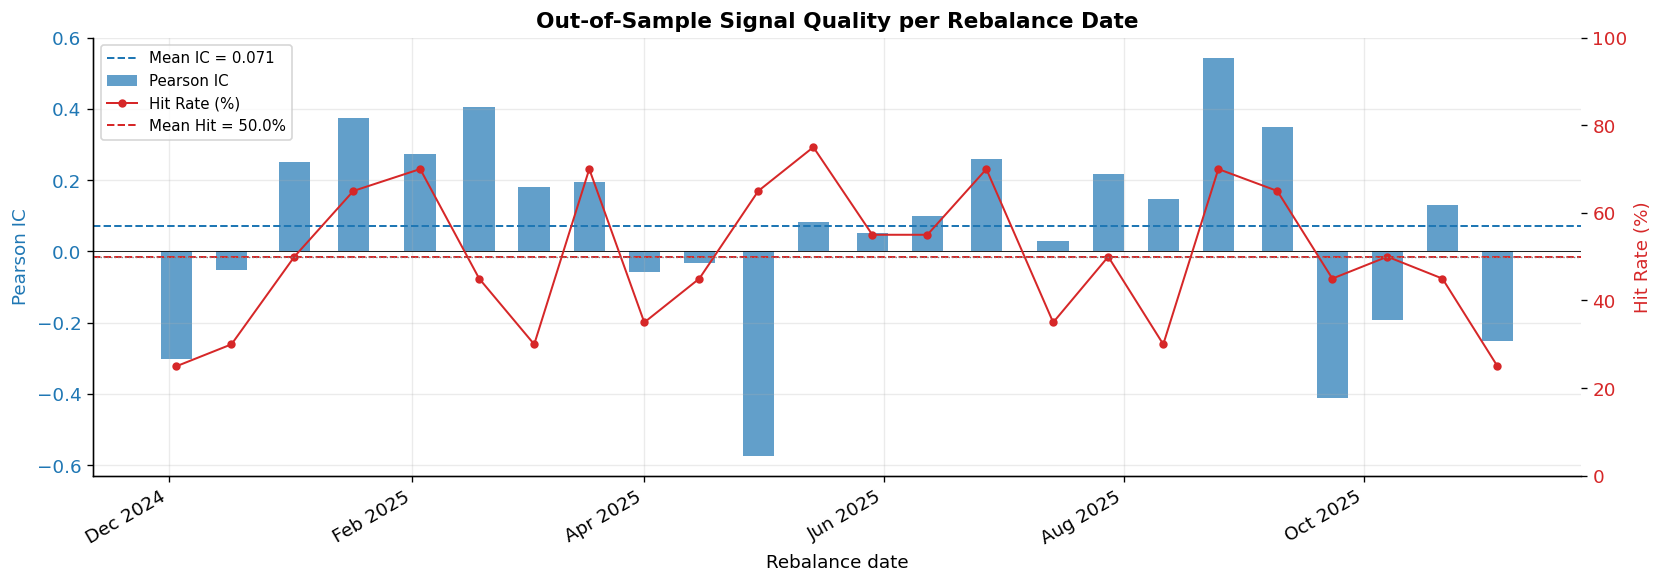

In [20]:
# Figure 8: Out-of-Sample Pearson IC and Hit Rate per Rebalance Date

target_col = f"fwd_return_{FWD_HORIZON}d"
ic_records = []

for rebal_date in adaptive_result.rebalance_dates:
    scores_on_date = {}
    returns_on_date = {}

    for ticker in TICKERS:
        ticker_df = feature_data.get(ticker)
        if ticker_df is None or rebal_date not in ticker_df.index:
            continue
        row = ticker_df.loc[rebal_date]
        if pd.isna(row.get(target_col)):
            continue

        # Get the composite score the model produced at this rebalance
        factor_vals  = row[FACTOR_COLS].values.astype(np.float32)
        context_vals = row[CONTEXT_COLS].values.astype(np.float32)

        with torch.no_grad():
            f_t = torch.tensor(factor_vals).unsqueeze(0).to(DEVICE)
            c_t = torch.tensor(context_vals).unsqueeze(0).to(DEVICE)
            score, _ = fusion_model(f_t, c_t)
            scores_on_date[ticker] = float(score.squeeze().cpu().item())

        returns_on_date[ticker] = float(row[target_col])

    if len(scores_on_date) < 4:
        continue

    tickers_common = sorted(scores_on_date.keys() & returns_on_date.keys())
    s = np.array([scores_on_date[t] for t in tickers_common])
    r = np.array([returns_on_date[t] for t in tickers_common])

    # Pearson IC
    s_c = s - s.mean()
    r_c = r - r.mean()
    denom = np.linalg.norm(s_c) * np.linalg.norm(r_c)
    ic = float(np.dot(s_c, r_c) / denom) if denom > 1e-10 else 0.0

    # Hit rate: fraction where sign(score) == sign(return)
    hit = float(np.mean(np.sign(s) == np.sign(r)))

    ic_records.append({"date": rebal_date, "IC": ic, "hit_rate": hit})

ic_df = pd.DataFrame(ic_records).set_index("date")

print(f"OOS Pearson IC  (mean): {ic_df['IC'].mean():.4f}")
print(f"OOS Hit Rate    (mean): {ic_df['hit_rate'].mean():.4f}")
print(f"Rebalance dates       : {len(ic_df)}")

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(ic_df.index, ic_df["IC"], width=8, color="#1f77b4", alpha=0.7, label="Pearson IC")
ax1.axhline(ic_df["IC"].mean(), color="#1f77b4", ls="--", lw=1.2,
            label=f"Mean IC = {ic_df['IC'].mean():.3f}")
ax1.axhline(0, color="black", lw=0.5)
ax1.set_ylabel("Pearson IC", color="#1f77b4")
ax1.set_xlabel("Rebalance date")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_title("Out-of-Sample Signal Quality per Rebalance Date", fontsize=13, fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(ic_df.index, ic_df["hit_rate"] * 100, color="#d62728", marker="o",
         ms=4, lw=1.2, label="Hit Rate (%)")
ax2.axhline(ic_df["hit_rate"].mean() * 100, color="#d62728", ls="--", lw=1.2,
            label=f"Mean Hit = {ic_df['hit_rate'].mean():.1%}")
ax2.axhline(50, color="gray", ls=":", lw=0.8)
ax2.set_ylabel("Hit Rate (%)", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2.set_ylim(0, 100)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

fmt_ax(ax1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "8_oos_ic_hit_rate.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Figure 9: Turnover and Transaction Cost Summary

avg_turnover = {}
for strategy_name, strategy_result in all_results.items():
    wh = strategy_result.weight_history
    if wh.empty or len(wh) < 2:
        continue
    turnover_per_rebal = wh.diff().abs().sum(axis=1).iloc[1:] / 2  # one-way turnover
    avg_turnover[strategy_name] = turnover_per_rebal.mean() * 100

print(f"{'Strategy':25s}  {'Trades':>6s}  {'Est. Costs':>12s}  {'Avg Turnover':>14s}  {'Rebalances':>10s}")
print("-" * 75)
for strategy_name, strategy_result in all_results.items():
    trades = strategy_result.trade_log
    if not trades:
        continue
    trade_df = pd.DataFrame(trades)
    sell_df = trade_df[trade_df["action"] == "SELL"]
    total_cost = sum(
        transaction_costs(row["value"], row["shares"])
        for _, row in sell_df.iterrows()
    )
    n_rebal = len(strategy_result.rebalance_dates)
    print(f"  {strategy_name:20s}  trades={len(trade_df):4d}  "
          f"est. total costs=${total_cost:.2f}  "
          f"avg turnover={avg_turnover.get(strategy_name, 0):.1f}%  "
          f"rebalances={n_rebal}")

Strategy                   Trades    Est. Costs    Avg Turnover  Rebalances
---------------------------------------------------------------------------
  Adaptive (WF)         trades= 196  est. total costs=$5.19  avg turnover=64.8%  rebalances=25
  Adaptive (Fixed)      trades= 196  est. total costs=$5.19  avg turnover=64.8%  rebalances=25
  Static-Fusion         trades= 194  est. total costs=$4.34  avg turnover=64.8%  rebalances=25
  Price-Only            trades= 181  est. total costs=$4.10  avg turnover=58.7%  rebalances=25


Stationary Bootstrap: 2000 resamples, geometric block length ~ 10 days
Strategy                     Sharpe              95% CI    p vs SPY
----------------------------------------------------------------------
  Adaptive (WF)             +1.2883  [-0.4738, +4.1856]      0.3490
  Adaptive (Fixed)          +1.2883  [-0.4817, +4.3371]      0.3215
  Static-Fusion             +0.3715  [-1.1539, +3.1283]      0.6205
  Price-Only                +0.9282  [-0.9604, +4.4474]      0.4510
  Equal-Weight              +1.1181  [-0.6614, +4.0115]      0.2830
  SPY Buy-and-Hold          +0.7481  [-0.7927, +3.3621]         ---


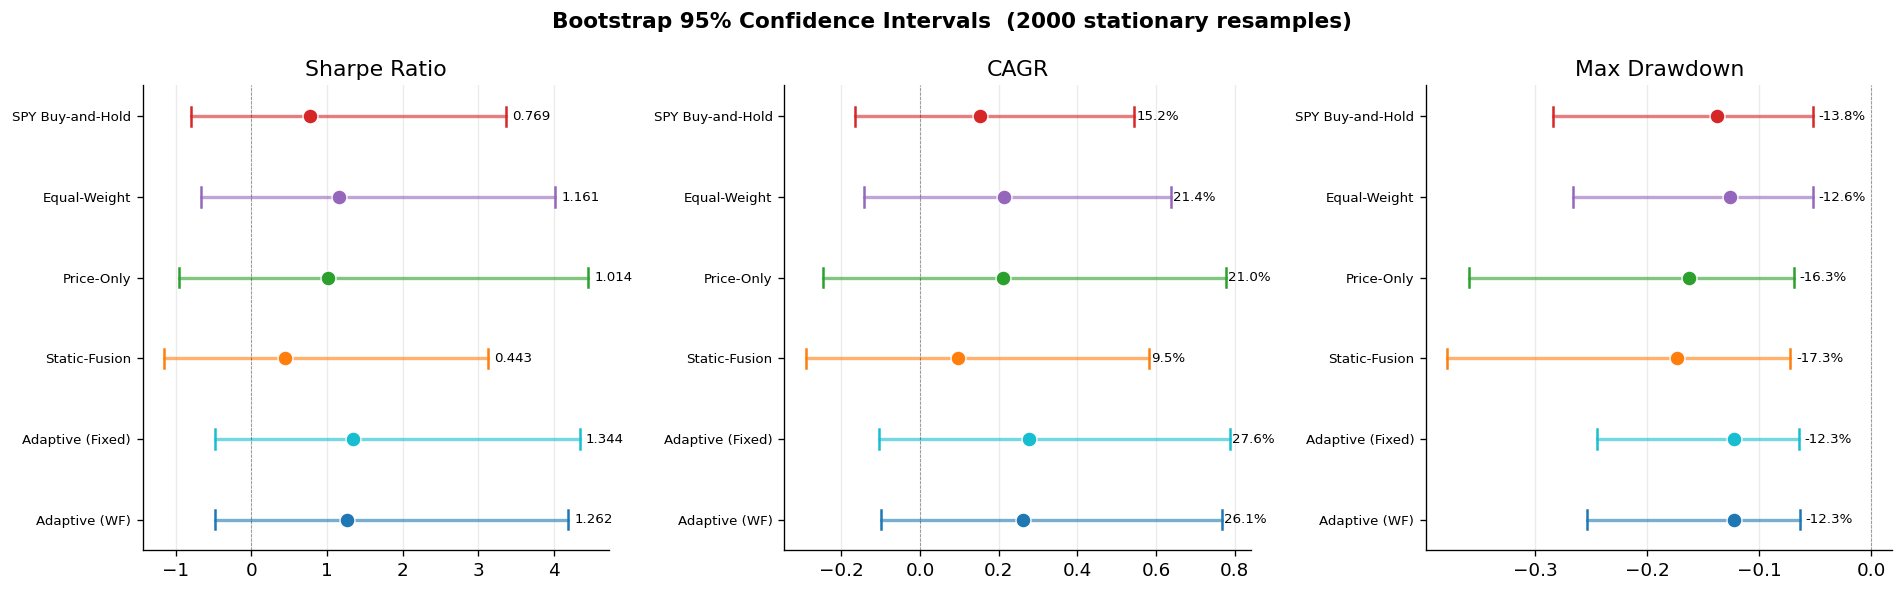


Bootstrap CI saved to C:\Users\alast\OneDrive - University of Greenwich\FYP\diagrams\AdaptiveFusionDiagram\bootstrap_ci.csv


In [22]:
# Figure 10: Stationary Bootstrap Confidence Intervals (2000 resamples)
N_BOOTSTRAP    = 2000
BLOCK_LENGTH   = 10   # geometric mean block length for stationary bootstrap

def stationary_bootstrap_indices(n, n_resamples, block_length):
    """Vectorised stationary bootstrap index generation (Politis & Romano, 1994).
    Pre-generates all random data upfront to minimise Python loop overhead."""
    p = 1.0 / block_length
    indices = np.empty((n_resamples, n), dtype=np.int64)
    # Pre-generate all random data in bulk (avoids per-iteration RNG calls)
    break_mask = np.random.random((n_resamples, n)) < p
    new_starts = np.random.randint(0, n, (n_resamples, n))
    break_mask[:, 0] = True  # always start fresh at t=0

    for b in range(n_resamples):
        idx = new_starts[b, 0]
        for t in range(n):
            if break_mask[b, t]:
                idx = new_starts[b, t]
            indices[b, t] = idx % n
            idx += 1
    return indices

def stationary_bootstrap(returns, n_resamples, block_length, indices=None):
    """Stationary bootstrap of Politis & Romano (1994).
    If indices are provided, uses those (for paired tests); otherwise generates new ones."""
    n = len(returns)
    if indices is None:
        indices = stationary_bootstrap_indices(n, n_resamples, block_length)
    return returns[indices]

# --- Vectorised metric computation (all 2000 resamples at once) ---

def compute_sharpes_vec(boot_matrix):
    """Compute Sharpe ratios for all resamples simultaneously. Shape: (B, T) -> (B,)"""
    n_days = boot_matrix.shape[1]
    cum = np.prod(1 + boot_matrix, axis=1)
    ann_ret = np.sign(cum) * np.abs(cum) ** (252 / n_days) - 1
    ann_vol = np.std(boot_matrix, axis=1, ddof=0) * np.sqrt(252)
    with np.errstate(divide='ignore', invalid='ignore'):
        sharpes = np.where(ann_vol > 0, ann_ret / ann_vol, 0.0)
    return sharpes

def compute_cagrs_vec(boot_matrix):
    """Compute CAGR for all resamples simultaneously. Shape: (B, T) -> (B,)"""
    n_days = boot_matrix.shape[1]
    years = n_days / 252
    cum = np.prod(1 + boot_matrix, axis=1)
    return np.sign(cum) * np.abs(cum) ** (1 / years) - 1

def compute_maxdds_vec(boot_matrix):
    """Compute max drawdown for all resamples simultaneously. Shape: (B, T) -> (B,)"""
    cum = np.cumprod(1 + boot_matrix, axis=1)
    running_max = np.maximum.accumulate(cum, axis=1)
    drawdowns = (cum - running_max) / running_max
    return np.min(drawdowns, axis=1)

np.random.seed(RANDOM_SEED)

boot_results = {}
for strategy_name, strategy_result in all_results.items():
    rets = strategy_result.returns_series.dropna().values
    if len(rets) < 20:
        continue
    boot_matrix = stationary_bootstrap(rets, N_BOOTSTRAP, BLOCK_LENGTH)
    sharpes = compute_sharpes_vec(boot_matrix)
    cagrs   = compute_cagrs_vec(boot_matrix)
    maxdds  = compute_maxdds_vec(boot_matrix)
    boot_results[strategy_name] = {
        "sharpe": sharpes, "cagr": cagrs, "maxdd": maxdds,
        "sharpe_ci": np.percentile(sharpes, [2.5, 97.5]),
        "cagr_ci":   np.percentile(cagrs,   [2.5, 97.5]),
        "maxdd_ci":  np.percentile(maxdds,  [2.5, 97.5]),
    }

# Paired bootstrap test: each strategy vs SPY (same block indices for both)
spy_rets = all_results["SPY Buy-and-Hold"].returns_series.dropna().values

print(f"Stationary Bootstrap: {N_BOOTSTRAP} resamples, geometric block length ~ {BLOCK_LENGTH} days")
print(f"{'Strategy':25s}  {'Sharpe':>8s}  {'95% CI':>18s}  {'p vs SPY':>10s}")
print("-" * 70)
for strategy_name in all_results:
    if strategy_name not in boot_results:
        continue
    br = boot_results[strategy_name]
    point = all_results[strategy_name].metrics.get("Sharpe Ratio", 0)
    ci = br["sharpe_ci"]
    if strategy_name == "SPY Buy-and-Hold":
        pval_str = "---"
    else:
        strat_rets = all_results[strategy_name].returns_series.dropna().values
        n_common = min(len(strat_rets), len(spy_rets))
        shared_indices = stationary_bootstrap_indices(n_common, N_BOOTSTRAP, BLOCK_LENGTH)
        paired_strat = stationary_bootstrap(strat_rets[:n_common], N_BOOTSTRAP, BLOCK_LENGTH, indices=shared_indices)
        paired_spy   = stationary_bootstrap(spy_rets[:n_common],   N_BOOTSTRAP, BLOCK_LENGTH, indices=shared_indices)
        paired_strat_sharpes = compute_sharpes_vec(paired_strat)
        paired_spy_sharpes   = compute_sharpes_vec(paired_spy)
        diff = paired_strat_sharpes - paired_spy_sharpes
        pval = (diff <= 0).mean()
        pval_str = f"{pval:.4f}"
    print(f"  {strategy_name:23s}  {point:+8.4f}  [{ci[0]:+.4f}, {ci[1]:+.4f}]  {pval_str:>10s}")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Bootstrap 95% Confidence Intervals  ({N_BOOTSTRAP} stationary resamples)",
             fontsize=13, fontweight="bold")

metrics_list = [
    ("sharpe", "sharpe_ci", "Sharpe Ratio"),
    ("cagr",   "cagr_ci",   "CAGR"),
    ("maxdd",  "maxdd_ci",  "Max Drawdown"),
]

for ax, (key, ci_key, title) in zip(axes, metrics_list):
    names, medians, lows, highs = [], [], [], []
    for strategy_name in all_results:
        if strategy_name not in boot_results:
            continue
        br = boot_results[strategy_name]
        ci = br[ci_key]
        names.append(strategy_name)
        medians.append(np.median(br[key]))
        lows.append(ci[0])
        highs.append(ci[1])

    y_pos = np.arange(len(names))
    colors_list = [COLORS.get(n, "grey") for n in names]

    # Scatter (forest) plot: point estimate + CI whiskers
    for i, (m, lo, hi, c) in enumerate(zip(medians, lows, highs, colors_list)):
        ax.plot([lo, hi], [i, i], color=c, linewidth=2, alpha=0.6,
                solid_capstyle="round")
        ax.plot([lo, lo], [i - 0.12, i + 0.12], color=c, linewidth=1.5)
        ax.plot([hi, hi], [i - 0.12, i + 0.12], color=c, linewidth=1.5)
        ax.scatter(m, i, color=c, s=80, zorder=5,
                   edgecolors="white", linewidths=0.8)
        if key in ("cagr", "maxdd"):
            ax.text(hi + 0.005, i, f"{m*100:.1f}%", va="center", fontsize=8)
        else:
            ax.text(hi + 0.08, i, f"{m:.3f}", va="center", fontsize=8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.25)
    ax.axvline(0, color="black", lw=0.5, ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_bootstrap_ci.png", dpi=300, bbox_inches="tight")
plt.show()

# Save bootstrap summary
boot_summary = []
for strategy_name in all_results:
    if strategy_name not in boot_results:
        continue
    br = boot_results[strategy_name]
    boot_summary.append({
        "Strategy": strategy_name,
        "Sharpe (point)": all_results[strategy_name].metrics.get("Sharpe Ratio", 0),
        "Sharpe 2.5%": br["sharpe_ci"][0],
        "Sharpe 97.5%": br["sharpe_ci"][1],
        "CAGR 2.5%": br["cagr_ci"][0],
        "CAGR 97.5%": br["cagr_ci"][1],
        "MaxDD 2.5%": br["maxdd_ci"][0],
        "MaxDD 97.5%": br["maxdd_ci"][1],
    })
pd.DataFrame(boot_summary).set_index("Strategy").to_csv(OUTPUT_DIR / "bootstrap_ci.csv")
print(f"\nBootstrap CI saved to {OUTPUT_DIR / 'bootstrap_ci.csv'}")


## 12. Rolling Window Analysis

Tests whether strategy performance is robust across different entry dates.
One start date is sampled per fortnight across the first 3 months from the backtest start, producing multiple rolling windows.
Each window runs for 12 months (1 year). Both walk-forward and fixed-model variants are evaluated.

In [23]:
def _metrics_from_rets(rets):
    """Compute Sharpe and Total Return from a 1-D array of daily returns."""
    rets = rets[~np.isnan(rets)]
    if len(rets) < 2:
        return {"Sharpe": np.nan, "Total Return": np.nan}
    ann_ret = (1 + rets).prod() ** (252 / len(rets)) - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    total   = (1 + rets).prod() - 1
    return {"Sharpe": round(sharpe, 4), "Total Return": round(total, 4)}


# Rolling windows: start dates span first 3 months, each window is 1 year
ROLL_WINDOW_MONTHS     = 12             # each window is 12 months (1 year)
ROLL_STEP_DAYS         = 5              # ~1 start date per week
ROLL_START_RANGE_MONTHS = 3              # start dates span first 3 months from backtest start

# Cache model weights in memory (avoids disk reads during the loop)
_cached_state = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)

rolling_fixed_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
rolling_fixed_model.load_state_dict(_cached_state)
rolling_fixed_model.to(DEVICE).eval()
print(f"Loaded trained model from {MODEL_PATH.name} (cached in memory for rolling windows)")

# Fetch SPY for the full rolling period (latest start + 12 months)
start_range_end = pd.Timestamp(BACKTEST_START) + pd.DateOffset(months=ROLL_START_RANGE_MONTHS)
roll_spy_end = (start_range_end + pd.DateOffset(months=ROLL_WINDOW_MONTHS + 1)).strftime("%Y-%m-%d")
print(f"Fetching extended SPY returns (to {roll_spy_end})")
spy_wide = fetch_spy_returns(BACKTEST_START, roll_spy_end)  # covers all possible window endpoints

# Extend price data to cover the latest rolling window endpoint
roll_price_end = roll_spy_end
print(f"Extending price data to {roll_price_end} for rolling windows ...")
price_data_extended = fetch_price_data(TICKERS, DATA_START, roll_price_end)
# Rebuild features on the extended data so backtests have full coverage
master_extended = build_master_dataset(price_data_extended, sentiment_data)
feature_data_extended = build_features(master_extended)

# One start date per fortnight from BACKTEST_START up to 3 months later
all_trading = sorted(price_data[TICKERS[0]].index)
eligible = [
    d for d in all_trading
    if pd.Timestamp(BACKTEST_START) <= d <= start_range_end
]
window_starts = eligible[::ROLL_STEP_DAYS]  # every 21st trading day ~ monthly

print(f"Window starts    : {len(window_starts)} (monthly, step={ROLL_STEP_DAYS} trading days)")
print(f"Window length    : {ROLL_WINDOW_MONTHS} months")
print(f"Start range      : {window_starts[0].date()}  to  {window_starts[-1].date()}")
print()

rolling_records = []

for i, start_dt in enumerate(window_starts, 1):
    end_dt    = start_dt + pd.DateOffset(months=ROLL_WINDOW_MONTHS)
    start_str = start_dt.strftime("%Y-%m-%d")
    end_str   = end_dt.strftime("%Y-%m-%d")

    try:
        # Walk-forward variant: clone from cached state (no disk I/O)
        wf_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
        wf_model.load_state_dict(_cached_state)
        wf_model.to(DEVICE).eval()

        r_wf = run_backtest(
            f"WF_{start_str}", feature_data_extended, price_data_extended,
            model=wf_model, use_sentiment=True, use_adaptive=True,
            start=start_str, end=end_str, retrain_every=RETRAIN_EVERY)
        m_wf = r_wf.metrics

        # Fixed variant: reuse the single cached model (read-only inference)
        r_fx = run_backtest(
            f"FX_{start_str}", feature_data_extended, price_data_extended,
            model=rolling_fixed_model, use_sentiment=True, use_adaptive=True,
            start=start_str, end=end_str, retrain_every=0)
        m_fx = r_fx.metrics
    except Exception as e:
        print(f"  [{i:3d}] {start_str} FAILED: {e}")
        continue

    if not m_wf or not m_fx:
        print(f"  [{i:3d}] {start_str} SKIPPED: backtest returned empty metrics")
        continue

    n_days_wf = len(r_wf.nav_series)

    spy_w = spy_wide.loc[start_str:end_str].dropna()
    spy_m = _metrics_from_rets(spy_w.values) if len(spy_w) >= 20 else None

    # Store NAV series for plotting
    if not hasattr(run_backtest, '_nav_store'):
        run_backtest._nav_store = {}
    run_backtest._nav_store[start_str] = {
        "WF": (r_wf.nav_series / r_wf.nav_series.iloc[0]) * 100,   # rebased to 100
        "FX": (r_fx.nav_series / r_fx.nav_series.iloc[0]) * 100,
        "SPY": None,
    }
    # Build SPY NAV for this window, trimmed to match the backtest date range
    if len(spy_w) >= 20:
        spy_nav = 100 * (1 + spy_w).cumprod()
        # Align SPY to the same end date as the backtest NAV
        bt_end = r_wf.nav_series.index[-1] if len(r_wf.nav_series) > 0 else None
        if bt_end is not None:
            spy_nav = spy_nav.loc[:bt_end]
        run_backtest._nav_store[start_str]["SPY"] = spy_nav

    rolling_records.append({
        "start":             start_dt,
        "end":               end_dt,
        "n_days":            n_days_wf,
        "WF_Sharpe":         m_wf["Sharpe Ratio"],
        "WF_Total_Return":   m_wf["Total Return"],
        "WF_Ann_Return":     m_wf["Annualised Return"],
        "WF_Max_Drawdown":   m_wf["Max Drawdown"],
        "FX_Sharpe":         m_fx["Sharpe Ratio"],
        "FX_Total_Return":   m_fx["Total Return"],
        "FX_Ann_Return":     m_fx["Annualised Return"],
        "FX_Max_Drawdown":   m_fx["Max Drawdown"],
        "SPY_Sharpe":        spy_m["Sharpe"]       if spy_m else np.nan,
        "SPY_Total_Return":  spy_m["Total Return"] if spy_m else np.nan,
    })

    if i % 5 == 0 or i == len(window_starts):
        spy_s = rolling_records[-1]["SPY_Sharpe"]
        print(f"  [{i:3d}/{len(window_starts)}] {start_str}  "
              f"WF={m_wf['Sharpe Ratio']:+.3f}  Fixed={m_fx['Sharpe Ratio']:+.3f}  SPY={spy_s:+.3f}")

rolling_df = pd.DataFrame(rolling_records)
rolling_df["WF_beats_spy"] = rolling_df["WF_Sharpe"] > rolling_df["SPY_Sharpe"]
rolling_df["FX_beats_spy"] = rolling_df["FX_Sharpe"] > rolling_df["SPY_Sharpe"]
rolling_df["WF_beats_FX"]  = rolling_df["WF_Sharpe"] > rolling_df["FX_Sharpe"]

# Summary
print(f"\nRolling {ROLL_WINDOW_MONTHS}-Month Window Summary  (n={len(rolling_df)})")
print("=" * 60)
for variant, prefix in [("Walk-Forward", "WF"), ("Fixed Model", "FX")]:
    cols = [f"{prefix}_Sharpe", f"{prefix}_Total_Return", f"{prefix}_Max_Drawdown"]
    desc = rolling_df[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    print(f"\n  {variant}:")
    display(desc.round(4))
    print(f"    Pct windows beating SPY : {rolling_df[f'{prefix}_beats_spy'].mean():.1%}")
print(f"  Walk-forward beats fixed : {rolling_df['WF_beats_FX'].mean():.1%}")

# Export
rolling_df.to_csv(OUTPUT_DIR / "rolling_window_results.csv", index=False)
print(f"\nResults saved to {OUTPUT_DIR / 'rolling_window_results.csv'}")

Loaded trained model from fusion_network.pt (cached in memory for rolling windows)
Fetching extended SPY returns (to 2026-04-01)
Extending price data to 2026-04-01 for rolling windows ...
Fetching daily OHLCV for 20 tickers ... done (20/20)
Features built: 20 tickers × 36 columns
Window starts    : 12 (monthly, step=5 trading days)
Window length    : 12 months
Start range      : 2024-12-02  to  2025-02-24

[WF_2024-12-02       ] Sharpe=+1.242 | Return=+25.8% | MaxDD=-14.2%
[FX_2024-12-02       ] Sharpe=+1.242 | Return=+25.8% | MaxDD=-14.2%
[WF_2024-12-09       ] Sharpe=+1.377 | Return=+26.9% | MaxDD=-9.7%
[FX_2024-12-09       ] Sharpe=+1.377 | Return=+26.9% | MaxDD=-9.7%
[WF_2024-12-16       ] Sharpe=+1.034 | Return=+21.8% | MaxDD=-14.2%
[FX_2024-12-16       ] Sharpe=+1.034 | Return=+21.8% | MaxDD=-14.2%
[WF_2024-12-23       ] Sharpe=+1.488 | Return=+30.0% | MaxDD=-9.7%
[FX_2024-12-23       ] Sharpe=+1.488 | Return=+30.0% | MaxDD=-9.7%
[WF_2024-12-31       ] Sharpe=+1.438 | Return=+29.

,WF_Sharpe,WF_Total_Return,WF_Max_Drawdown
count,12.0000,12.0000,12.0000
mean,1.2982,0.2596,-0.1252
std,0.3848,0.0724,0.0312
min,0.3753,0.0780,-0.1854
5%,0.7041,0.1450,-0.1713
25%,1.0972,0.2254,-0.1430
50%,1.4077,0.2752,-0.1204
75%,1.5202,0.3044,-0.0971
95%,1.7319,0.3354,-0.0970
max,1.7530,0.3399,-0.0968


    Pct windows beating SPY : 91.7%

  Fixed Model:


,FX_Sharpe,FX_Total_Return,FX_Max_Drawdown
count,12.0000,12.0000,12.0000
mean,1.2982,0.2596,-0.1252
std,0.3848,0.0724,0.0312
min,0.3753,0.0780,-0.1854
5%,0.7041,0.1450,-0.1713
25%,1.0972,0.2254,-0.1430
50%,1.4077,0.2752,-0.1204
75%,1.5202,0.3044,-0.0971
95%,1.7319,0.3354,-0.0970
max,1.7530,0.3399,-0.0968


    Pct windows beating SPY : 91.7%
  Walk-forward beats fixed : 0.0%

Results saved to C:\Users\alast\OneDrive - University of Greenwich\FYP\diagrams\AdaptiveFusionDiagram\rolling_window_results.csv


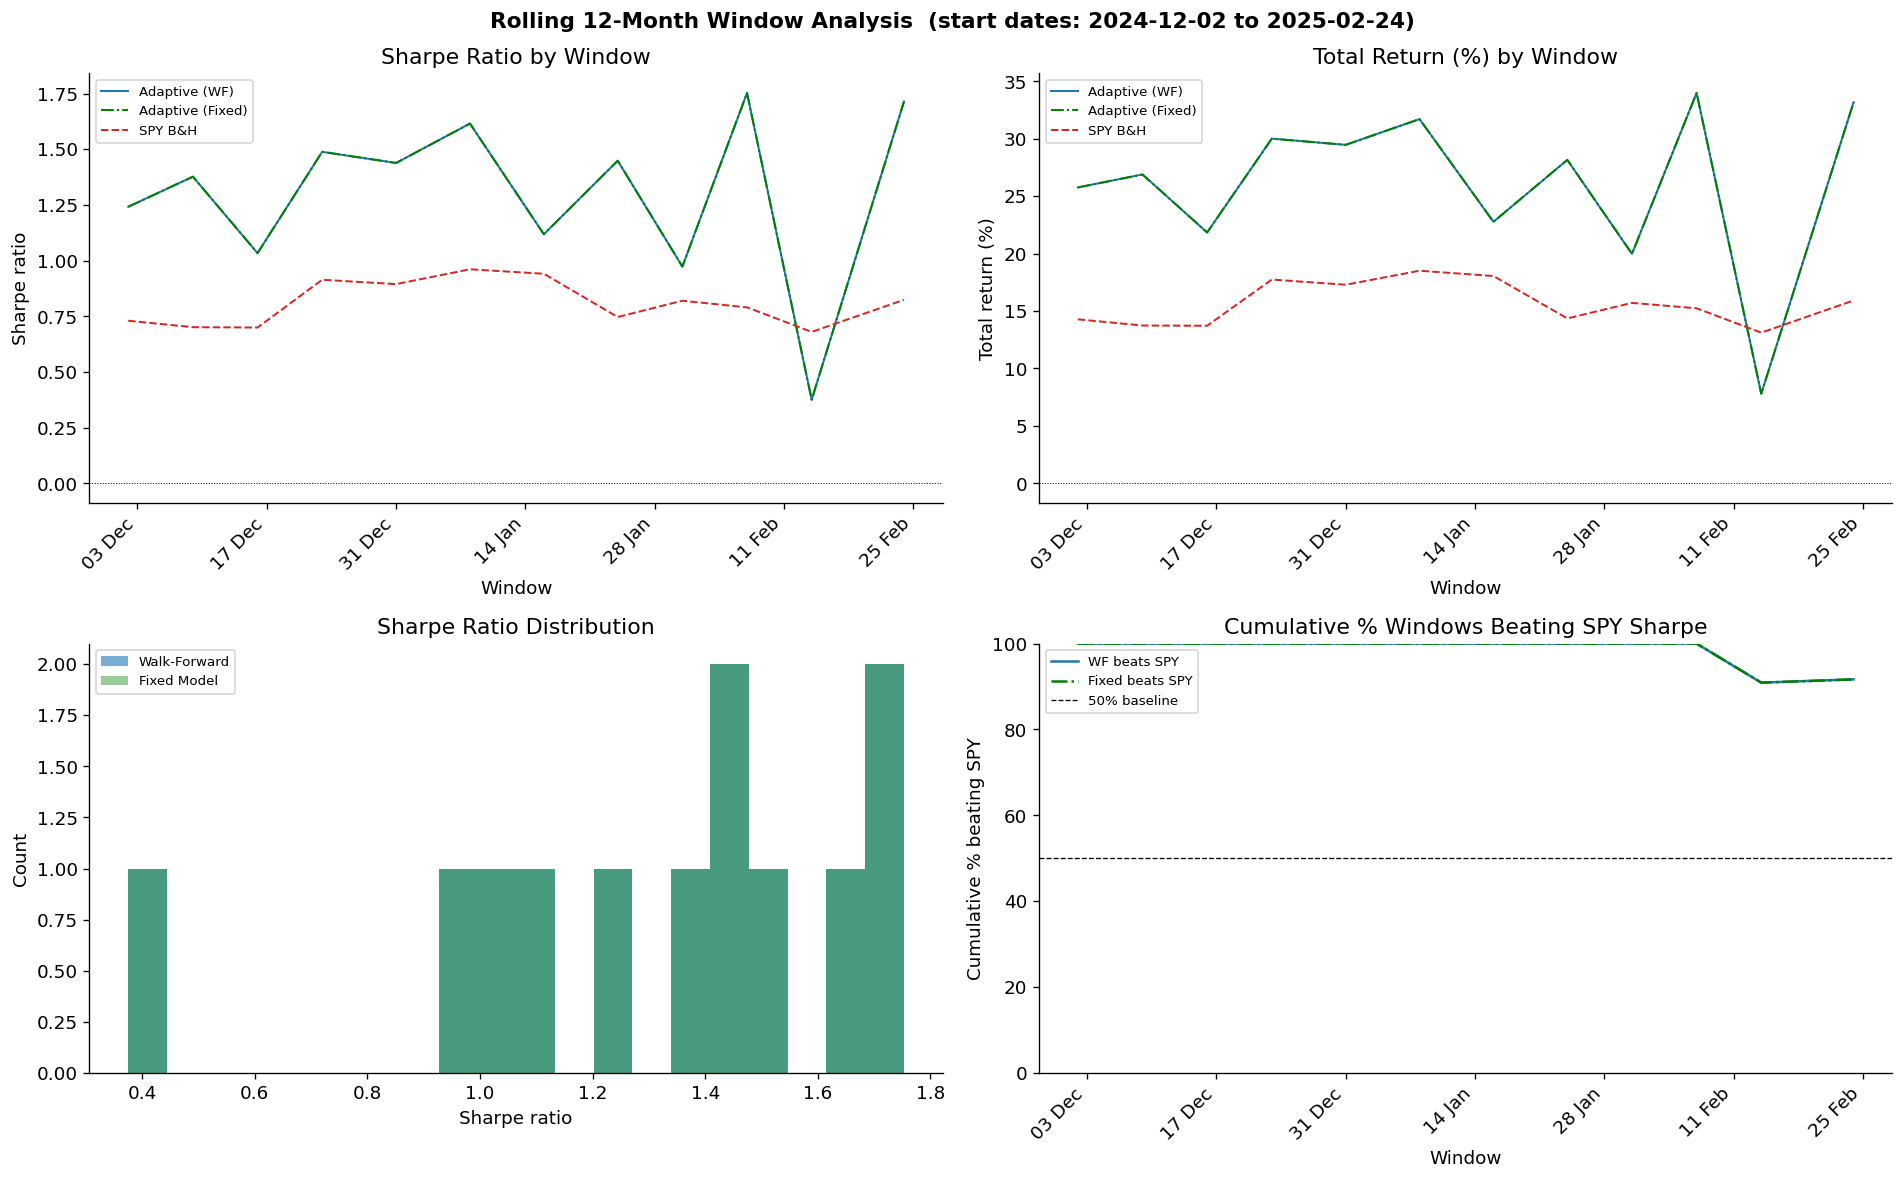

In [24]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"Rolling 12-Month Window Analysis  (start dates: {window_starts[0].date()} to {window_starts[-1].date()})",
             fontsize=13, fontweight="bold")

# Create window labels showing start-end range
rolling_df["window_label"] = [
    f"{s.strftime('%d %b %y')} – {e.strftime('%d %b %y')}"
    for s, e in zip(rolling_df["start"], rolling_df["end"])
]

def _apply_month_fmt(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Top-left: Sharpe ratio
ax = axes[0, 0]
ax.plot(rolling_df["start"], rolling_df["WF_Sharpe"],
        color="#1f77b4", linewidth=1.2, label="Adaptive (WF)")
ax.plot(rolling_df["start"], rolling_df["FX_Sharpe"],
        color="green", linewidth=1.2, linestyle="-.", label="Adaptive (Fixed)")
ax.plot(rolling_df["start"], rolling_df["SPY_Sharpe"],
        color="#d62728", linewidth=1.2, linestyle="--", label="SPY B&H")
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Sharpe Ratio by Window")
ax.set_xlabel("Window")
ax.set_ylabel("Sharpe ratio")
ax.legend(fontsize=8)
_apply_month_fmt(ax)

# Top-right: Total return
ax = axes[0, 1]
ax.plot(rolling_df["start"], rolling_df["WF_Total_Return"] * 100,
        color="#1f77b4", linewidth=1.2, label="Adaptive (WF)")
ax.plot(rolling_df["start"], rolling_df["FX_Total_Return"] * 100,
        color="green", linewidth=1.2, linestyle="-.", label="Adaptive (Fixed)")
ax.plot(rolling_df["start"], rolling_df["SPY_Total_Return"] * 100,
        color="#d62728", linewidth=1.2, linestyle="--", label="SPY B&H")
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Total Return (%) by Window")
ax.set_xlabel("Window")
ax.set_ylabel("Total return (%)")
ax.legend(fontsize=8)
_apply_month_fmt(ax)

# Bottom-left: Sharpe histogram (WF vs Fixed)
ax = axes[1, 0]
bins = 20
ax.hist(rolling_df["WF_Sharpe"], bins=bins,
        alpha=0.6, color="#1f77b4", label="Walk-Forward")
ax.hist(rolling_df["FX_Sharpe"], bins=bins,
        alpha=0.4, color="green", label="Fixed Model")
ax.set_title("Sharpe Ratio Distribution")
ax.set_xlabel("Sharpe ratio")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# Bottom-right: Cumulative % windows beating SPY
ax = axes[1, 1]
cum_beat_wf = rolling_df["WF_beats_spy"].expanding().mean() * 100
cum_beat_fx = rolling_df["FX_beats_spy"].expanding().mean() * 100
ax.plot(rolling_df["start"], cum_beat_wf,
        color="#1f77b4", linewidth=1.5, label="WF beats SPY")
ax.plot(rolling_df["start"], cum_beat_fx,
        color="green", linewidth=1.5, linestyle="-.", label="Fixed beats SPY")
ax.axhline(50, color="black", linewidth=0.8, linestyle="--", label="50% baseline")
ax.set_title("Cumulative % Windows Beating SPY Sharpe")
ax.set_xlabel("Window")
ax.set_ylabel(f"Cumulative % beating SPY")
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
_apply_month_fmt(ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_rolling_window.png", dpi=300, bbox_inches="tight")
plt.show()

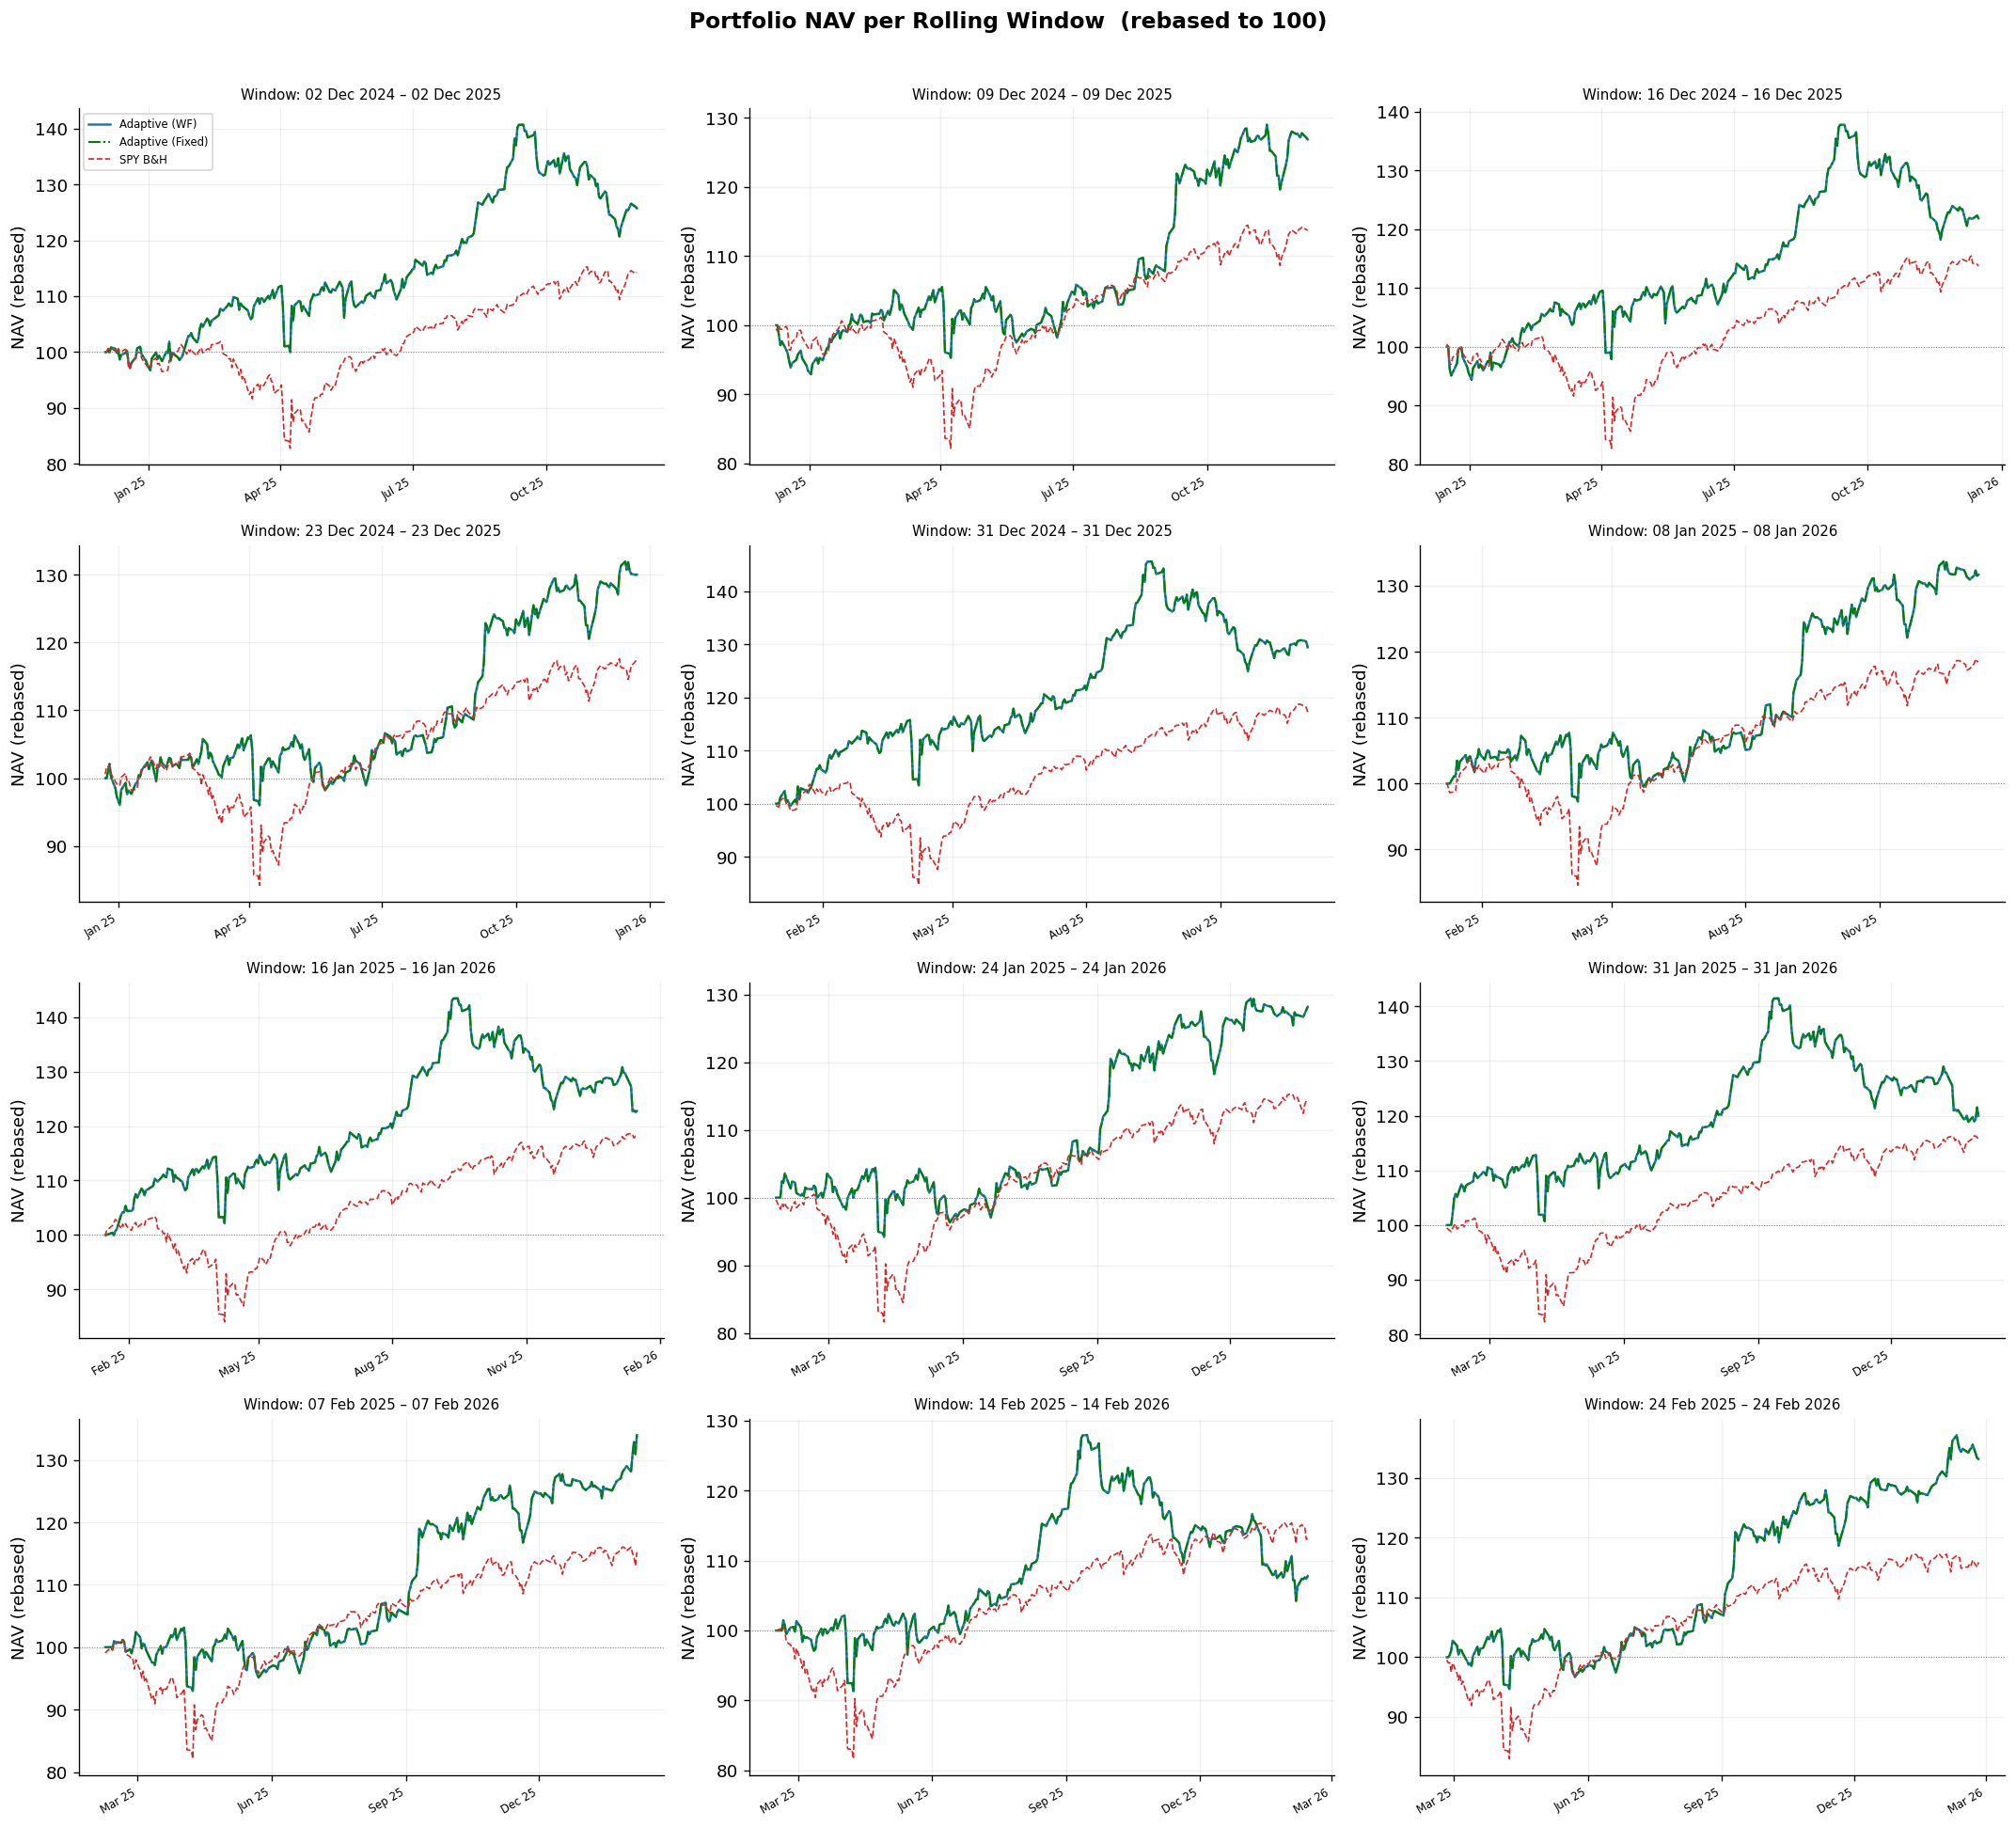

Saved: C:\Users\alast\OneDrive - University of Greenwich\FYP\diagrams\AdaptiveFusionDiagram\12_rolling_window_nav.png


In [25]:
# Figure 12: Portfolio NAV trajectories for each rolling window
nav_store = getattr(run_backtest, "_nav_store", {})
n_windows = len(nav_store)

if n_windows == 0:
    print("No NAV data stored â€” rerun the rolling window cell first.")
else:
    ncols = min(3, n_windows)
    nrows = (n_windows + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=False)
    fig.suptitle("Portfolio NAV per Rolling Window  (rebased to 100)",
                 fontsize=14, fontweight="bold", y=1.01)

    if n_windows == 1:
        axes = np.array([axes])
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for idx, (start_str, navs) in enumerate(sorted(nav_store.items())):
        ax = axes_flat[idx]
        if navs["WF"] is not None and len(navs["WF"]) > 0:
            ax.plot(navs["WF"].index, navs["WF"].values,
                    color="#1f77b4", linewidth=1.5, label="Adaptive (WF)")
        if navs["FX"] is not None and len(navs["FX"]) > 0:
            ax.plot(navs["FX"].index, navs["FX"].values,
                    color="green", linewidth=1.2, linestyle="-.", label="Adaptive (Fixed)")
        if navs["SPY"] is not None and len(navs["SPY"]) > 0:
            ax.plot(navs["SPY"].index, navs["SPY"].values,
                    color="#d62728", linewidth=1.0, linestyle="--", label="SPY B&H")

        ax.axhline(100, color="grey", linewidth=0.6, linestyle=":")
        end_str_label = (pd.Timestamp(start_str) + pd.DateOffset(months=ROLL_WINDOW_MONTHS)).strftime("%d %b %Y")
        start_label = pd.Timestamp(start_str).strftime("%d %b %Y")
        ax.set_title(f"Window: {start_label} – {end_str_label}", fontsize=9)
        ax.set_ylabel("NAV (rebased)")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
        ax.grid(True, alpha=0.2)
        if idx == 0:
            ax.legend(fontsize=7, loc="upper left")

    # Hide unused subplots
    for j in range(n_windows, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "12_rolling_window_nav.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {OUTPUT_DIR / "12_rolling_window_nav.png"}")


---
## 13. Attention Diagnostic: Per-Sector Ticker Trace 

Fixes one representative ticker per sector and runs inference at every rebalance date using
the pretrained `fusion_model`. Since the sector one-hot encoding never changes for a given ticker,
**any variation in the attention line is caused solely by the three time-varying context
features** (volatility regime, news intensity, social intensity).

- **Flat line** = the model learned a static sector preference; regime has no effect for that ticker
- **Visible movement** = the model genuinely adapts to changing market conditions

This isolates the regime signal from the portfolio-composition confound in Figure 4.

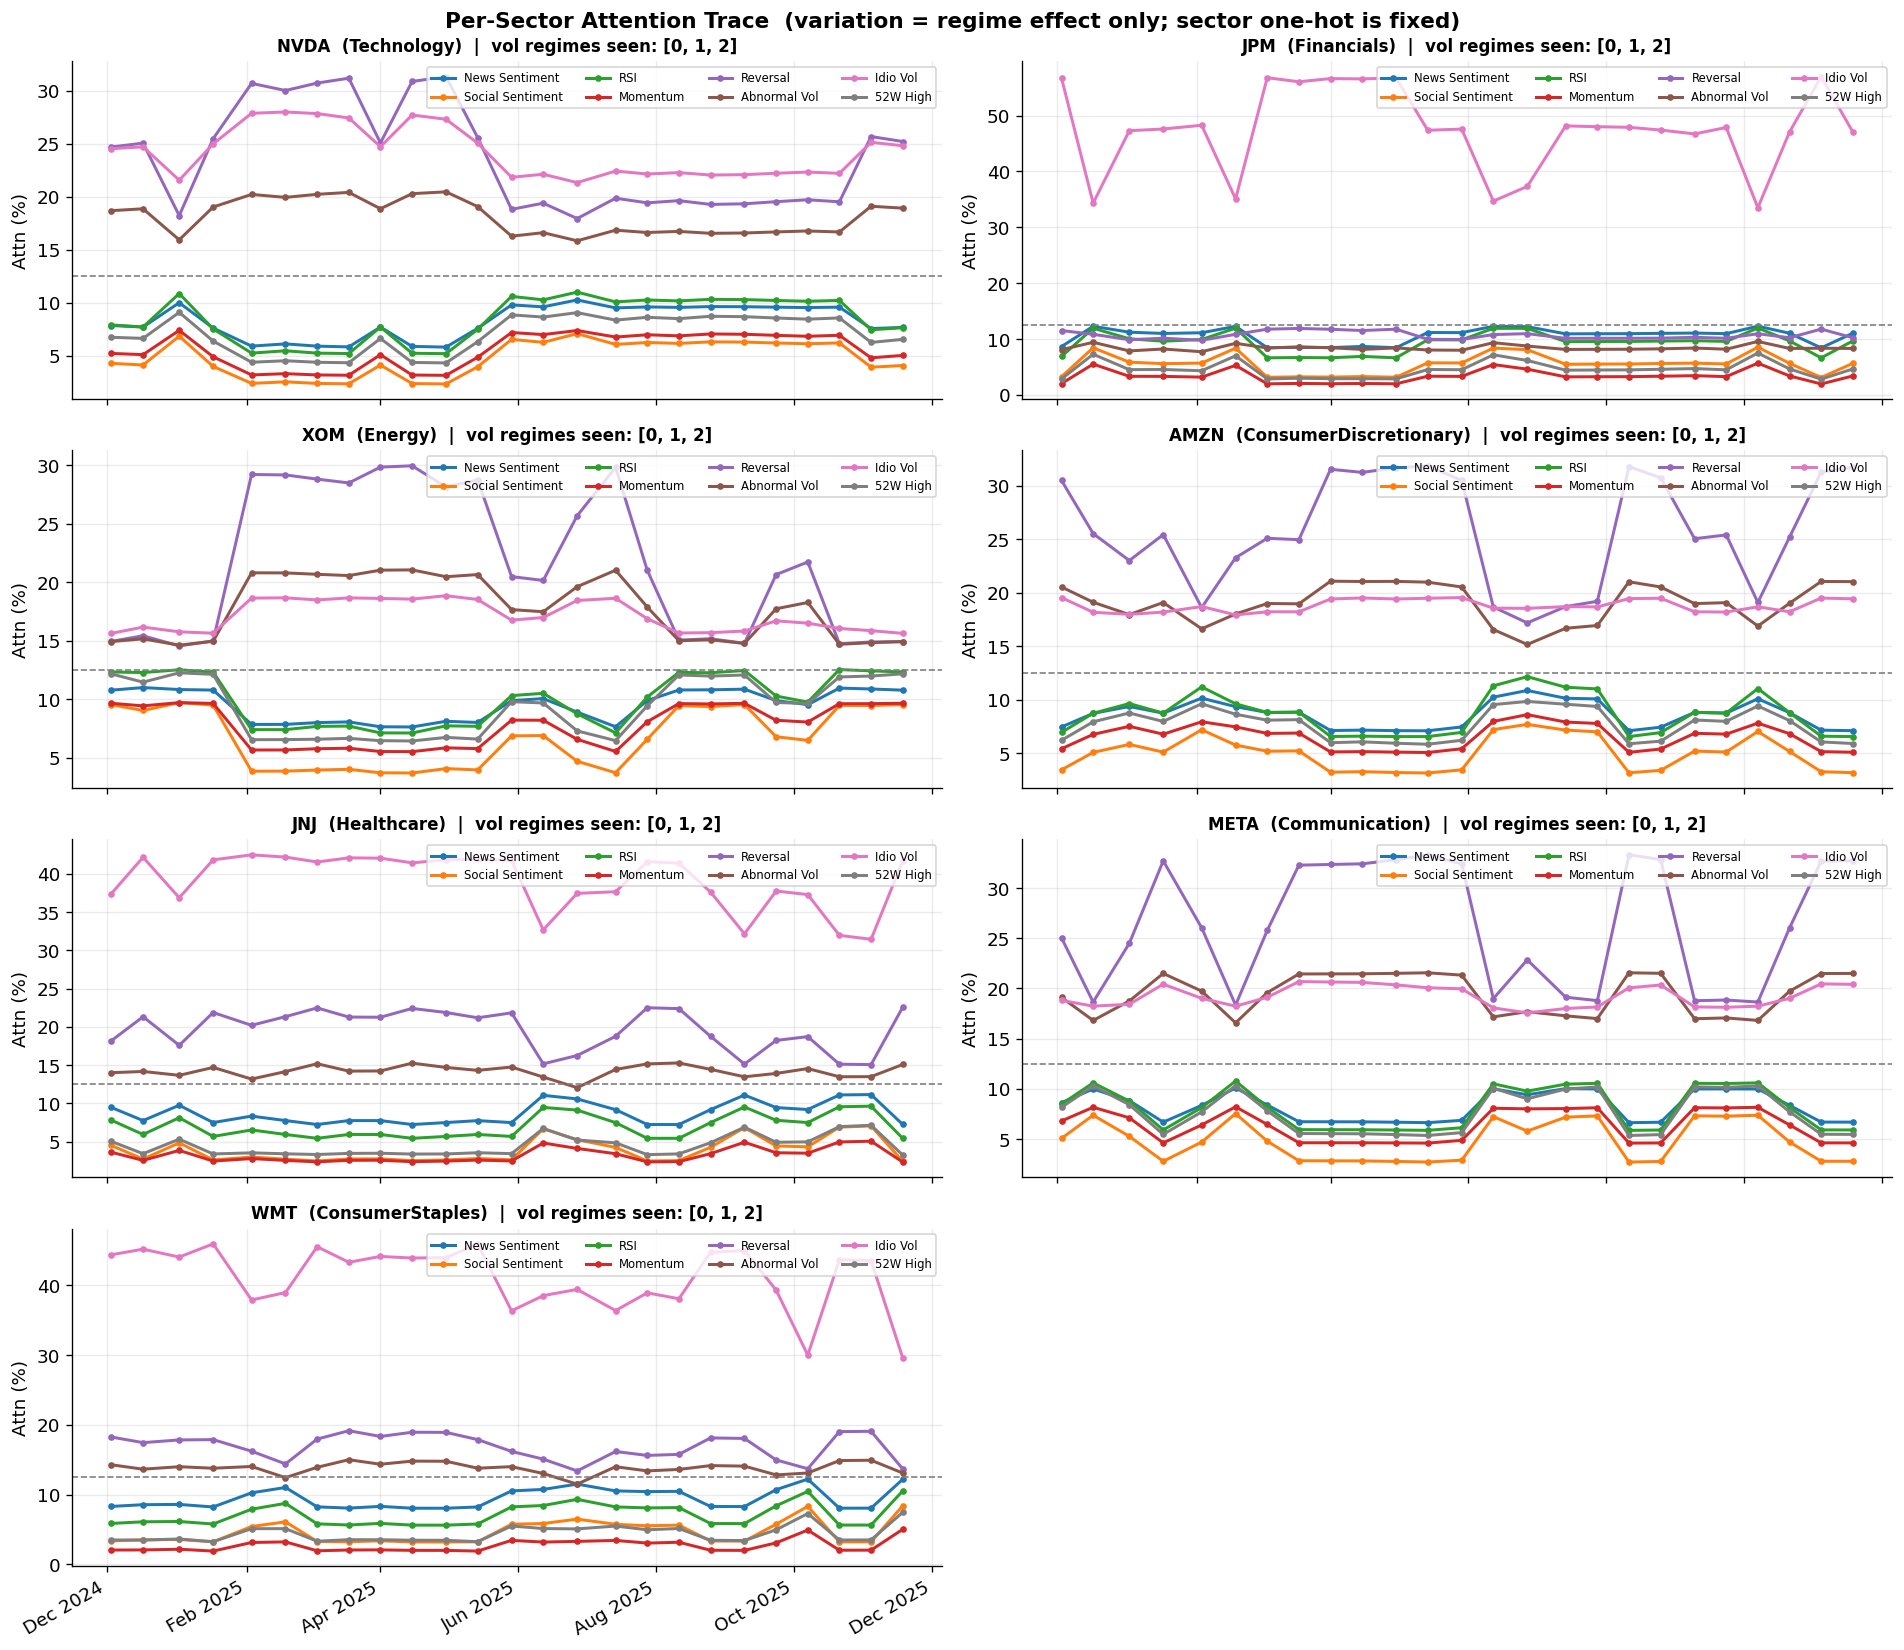

In [26]:
# Option A: per-sector ticker attention trace (fixed model, one rep per sector)
SECTOR_REPS = {
    "Technology":            "NVDA",
    "Financials":            "JPM",
    "Energy":                "XOM",
    "ConsumerDiscretionary": "AMZN",
    "Healthcare":            "JNJ",
    "Communication":         "META",
    "ConsumerStaples":       "WMT",
}
FACTOR_DISPLAY = ["News Sentiment", "Social Sentiment", "RSI", "Momentum",
                  "Reversal", "Abnormal Vol", "Idio Vol", "52W High"]

rebal_dates = adaptive_result.rebalance_dates
color_map   = plt.get_cmap("tab10")
ncols = 2
nrows = (len(SECTOR_REPS) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=True)
axes_flat  = axes.flatten()

fusion_model.eval()
for ax_idx, (sector, ticker) in enumerate(SECTOR_REPS.items()):
    ax = axes_flat[ax_idx]
    attn_rows = []
    vol_vals  = []
    for date in rebal_dates:
        if ticker not in feature_data or date not in feature_data[ticker].index:
            continue
        row   = feature_data[ticker].loc[date]
        f_ten = torch.tensor(row[FACTOR_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
        c_ten = torch.tensor(row[CONTEXT_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _, attn = fusion_model(f_ten, c_ten)
        attn_rows.append({"date": date,
                          **{f: float(v) for f, v in zip(FACTOR_DISPLAY, attn.squeeze().cpu().numpy())}})
        vol_vals.append(int(row["volatility_regime"]))
    if not attn_rows:
        ax.set_visible(False)
        continue
    df = pd.DataFrame(attn_rows).set_index("date")
    for i, col in enumerate(df.columns):
        ax.plot(df.index, df[col] * 100, label=col, lw=1.8, marker="o", ms=3, color=color_map(i))
    ax.axhline(100 / len(FACTOR_DISPLAY), color="grey", ls="--", lw=1)
    regimes_seen = sorted(set(vol_vals))
    ax.set_title(f"{ticker}  ({sector})  |  vol regimes seen: {regimes_seen}",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Attn (%)")
    ax.legend(fontsize=7, ncol=4, loc="upper right")
    fmt_ax(ax)

if len(SECTOR_REPS) % ncols:
    axes_flat[-1].set_visible(False)

fig.suptitle("Per-Sector Attention Trace  (variation = regime effect only; sector one-hot is fixed)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "6_attention_per_sector_ticker.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 14. Attention Diagnostic: Grouped by Volatility Regime

Runs inference for **all 20 tickers** at every rebalance date and groups the resulting
attention weights by each ticker's `volatility_regime` (0 = low, 1 = mid, 2 = high).
Error bars show one standard deviation across the grouped observations.

- **Bars at the same height across regimes** = the model does not differentiate by volatility; sector drives everything
- **Bars that differ across regimes** = the model has learned genuine regime-conditional factor preferences

This directly tests whether the three time-varying context inputs have any learned effect.

Observations per regime: {0: 2797, 1: 3808, 2: 5115}


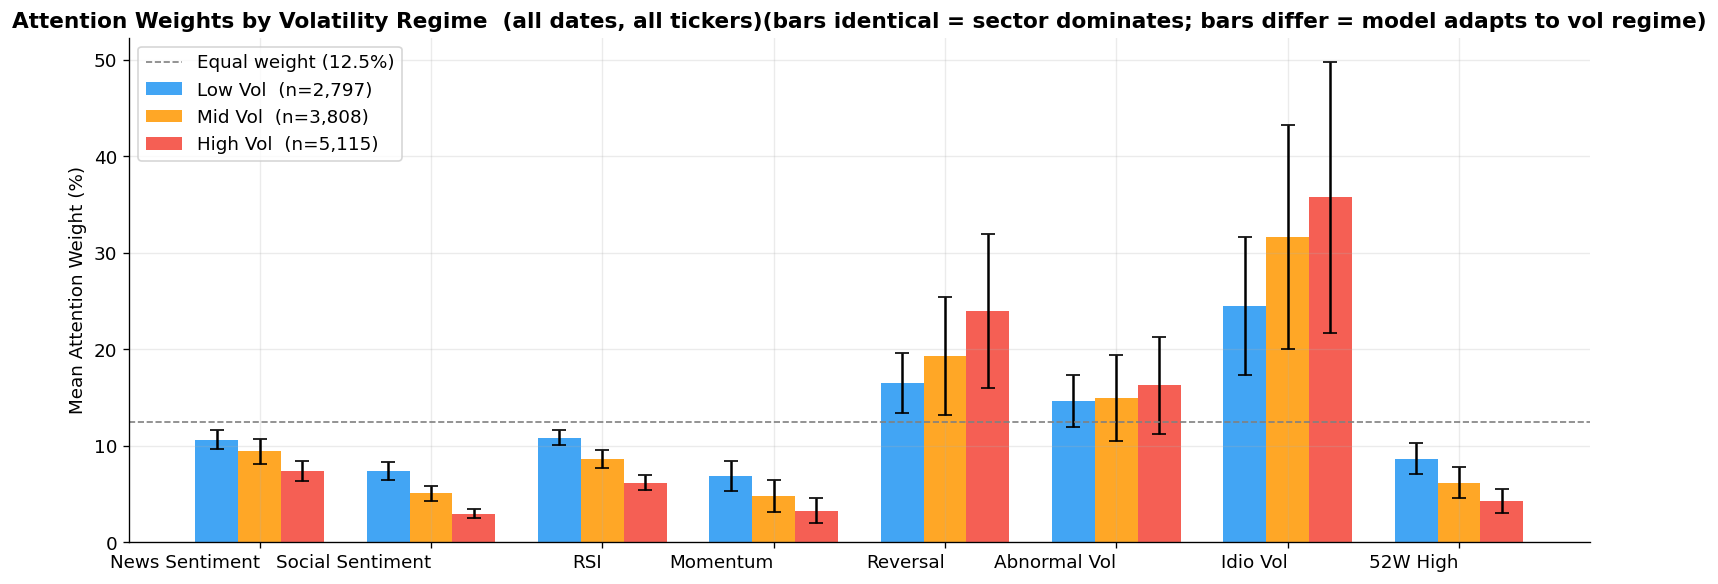

Figure 7 saved.


In [27]:
# Option B: attention grouped by volatility regime (all tickers, all available dates)
from collections import defaultdict

regime_attn    = defaultdict(list)
FACTOR_DISPLAY = ["News Sentiment", "Social Sentiment", "RSI", "Momentum",
                  "Reversal", "Abnormal Vol", "Idio Vol", "52W High"]

# Use all dates in feature_data (training + backtest) for a large, balanced sample
all_dates = sorted(set(
    date
    for df in feature_data.values()
    for date in df.index
    if df.loc[date, FACTOR_COLS + CONTEXT_COLS].notna().all()
))

fusion_model.eval()
with torch.no_grad():
    for date in all_dates:
        for ticker in TICKERS:
            if ticker not in feature_data or date not in feature_data[ticker].index:
                continue
            row = feature_data[ticker].loc[date]
            if row[FACTOR_COLS + CONTEXT_COLS].isna().any():
                continue
            regime = int(row["volatility_regime"])
            f_ten  = torch.tensor(row[FACTOR_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
            c_ten  = torch.tensor(row[CONTEXT_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
            _, attn = fusion_model(f_ten, c_ten)
            regime_attn[regime].append(attn.squeeze().cpu().numpy())

print(f"Observations per regime: { {k: len(v) for k, v in sorted(regime_attn.items())} }")

regime_names  = {0: "Low Vol",  1: "Mid Vol",  2: "High Vol"}
regime_colors = {0: "#2196F3",  1: "#FF9800",  2: "#F44336"}
x     = np.arange(len(FACTOR_DISPLAY))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, regime in enumerate([0, 1, 2]):
    vecs = regime_attn.get(regime, [])
    if not vecs:
        continue
    arr   = np.stack(vecs)
    means = arr.mean(axis=0) * 100
    stds  = arr.std(axis=0)  * 100
    label = f"{regime_names[regime]}  (n={len(vecs):,})"
    ax.bar(x + i * width, means, width, yerr=stds, capsize=4,
           label=label, color=regime_colors[regime], alpha=0.85)

ax.axhline(100 / len(FACTOR_DISPLAY), color="grey", ls="--", lw=1,
           label=f"Equal weight ({100/len(FACTOR_DISPLAY):.1f}%)")
ax.set_ylabel("Mean Attention Weight (%)")
ax.set_title(
    "Attention Weights by Volatility Regime  (all dates, all tickers)"
    "(bars identical = sector dominates; bars differ = model adapts to vol regime)",
    fontsize=13, fontweight="bold")
ax.legend()
fmt_ax(ax)
# reset x-axis after fmt_ax -- fmt_ax applies date formatting which corrupts categorical ticks
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.NullFormatter())
ax.set_xticks(x + width)
ax.set_xticklabels(FACTOR_DISPLAY, rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "7_attention_by_vol_regime.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 7 saved.")

---
## 15. Step-by-Step Pipeline Walkthrough (Single Ticker)

Traces the full computation for one ticker on one rebalance date with real numbers,
showing exactly what value flows through each stage.

In [28]:
# Full pipeline walkthrough for one ticker on one rebalance date
TRACE_TICKER = "NVDA"
TRACE_DATE   = adaptive_result.rebalance_dates[len(adaptive_result.rebalance_dates) // 2]
FACTOR_DISPLAY  = ["News Sent", "Social Sent", "RSI", "Momentum",
                   "Reversal", "Abnormal Vol", "Idio Vol", "52W High"]
CONTEXT_DISPLAY = ["Vol Regime", "News Intensity", "Social Intensity"] + [f"sector_{s}" for s in SECTORS]

print(f"Ticker : {TRACE_TICKER}")
print(f"Date   : {TRACE_DATE.date()}")
print("=" * 62)

row          = feature_data[TRACE_TICKER].loc[TRACE_DATE]
factor_vals  = row[FACTOR_COLS].values.astype("float32")
context_vals = row[CONTEXT_COLS].values.astype("float32")

# Step 1: Inputs
print("STEP 1 - Inputs")
print(f"  Factor vector  ({N_FACTORS} Z-scored values, fed to weighted fusion):")
for name, val in zip(FACTOR_DISPLAY, factor_vals):
    print(f"    {name:<18s}  {val:+.4f}")
print("  Context vector (10 values, fed to attention head):")
for name, val in zip(CONTEXT_DISPLAY, context_vals):
    print(f"    {name:<28s}  {val:.4f}")

# Step 2: Context encoder + attention head
f_ten = torch.tensor(factor_vals).unsqueeze(0).to(DEVICE)
c_ten = torch.tensor(context_vals).unsqueeze(0).to(DEVICE)

fusion_model.eval()
with torch.no_grad():
    encoded      = fusion_model.context_encoder(c_ten)
    logits       = fusion_model.attention_logits(encoded)
    attn_weights = torch.softmax(logits / SOFTMAX_TEMP, dim=-1)
    score_tensor, _ = fusion_model(f_ten, c_ten)

attn_np = attn_weights.squeeze().cpu().numpy()
score   = float(score_tensor.squeeze().cpu().item())

print(f"STEP 2 - Context Encoder  Linear(10->32) -> ReLU -> Dropout")
print(f"  Output shape: {tuple(encoded.shape)}   range [{encoded.min().item():+.3f}, {encoded.max().item():+.3f}]")

# Step 3: Attention weights
eq = 100 / len(FACTOR_DISPLAY)
print(f"STEP 3 - Attention Head  Linear(32->16) -> ReLU -> Linear(16->{N_FACTORS}) -> Softmax(T={SOFTMAX_TEMP})")
print(f"  {'Factor':<18s}  {'Weight':>7s}  Bar")
for name, w in zip(FACTOR_DISPLAY, attn_np):
    bar  = "=" * int(w * 300)
    flag = " <-- above equal" if w * 100 > eq else ""
    print(f"  {name:<18s}  {w*100:6.2f}%  {bar}{flag}")
print(f"  Equal weight = {eq:.2f}%   |   sum = {attn_np.sum():.6f}")

# Step 4: Weighted fusion
contrib = attn_np * factor_vals
print(f"STEP 4 - Weighted Fusion   composite = sum(attention_i x z_factor_i)")
print(f"  {'Factor':<18s}  {'Attn':>7s}  {'Z-score':>8s}  {'Contribution':>14s}")
print(f"  {'-'*55}")
for name, w, z, c in zip(FACTOR_DISPLAY, attn_np, factor_vals, contrib):
    print(f"  {name:<18s}  {w*100:6.2f}%  {z:+8.4f}  {c:+14.6f}")
print(f"  {'-'*55}")
print(f"  {'Composite score':<18s}  {'':7s}  {'':8s}  {score:+14.6f}")

# Step 5: All-ticker scores and ranking
all_scores = {}
with torch.no_grad():
    for t in TICKERS:
        if t not in feature_data or TRACE_DATE not in feature_data[t].index:
            continue
        r2 = feature_data[t].loc[TRACE_DATE]
        if r2[FACTOR_COLS + CONTEXT_COLS].isna().any():
            continue
        ft = torch.tensor(r2[FACTOR_COLS].values.astype("float32")).unsqueeze(0).to(DEVICE)
        ct = torch.tensor(r2[CONTEXT_COLS].values.astype("float32")).unsqueeze(0).to(DEVICE)
        s, _ = fusion_model(ft, ct)
        all_scores[t] = float(s.squeeze().cpu().item())

ranked = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)
print(f"STEP 5 - Cross-Sectional Ranking  ({len(ranked)} tickers scored)")
for i, (t, s) in enumerate(ranked):
    tag    = " <-- SELECTED" if i < 5 else ""
    marker = ">>>" if t == TRACE_TICKER else "   "
    print(f"  {marker} #{i+1:2d}  {t:<6s}  {s:+.4f}{tag}")

# Step 6: BL view scaling
import numpy as np
score_arr = np.array(list(all_scores.values()))
score_std = float(score_arr.std())
selected  = [t for t, _ in ranked[:5]]
close_df  = pd.DataFrame({t: feature_data[t]["Close"] for t in selected if t in feature_data}).sort_index()
close_df  = close_df[close_df.index <= TRACE_DATE].tail(30)
ret_std   = float(close_df.pct_change().dropna().std().mean())
view_q    = (score / score_std * ret_std) if score_std > 1e-8 else 0.0

print(f"STEP 6 - Scale to Return Units   Q = score / score_std * return_std")
print(f"  score_std  = {score_std:.6f}  (cross-sectional std across all tickers)")
print(f"  return_std = {ret_std:.6f}  (mean 30-day daily return std, top-5)")
print(f"  Raw score  = {score:+.6f}")
print(f"  BL view Q  = {view_q:+.6f}  (~{view_q*100:+.4f}% expected daily return for {TRACE_TICKER})")

Ticker : NVDA
Date   : 2025-05-29
STEP 1 - Inputs
  Factor vector  (8 Z-scored values, fed to weighted fusion):
    News Sent           +0.1772
    Social Sent         +0.6608
    RSI                 +1.2078
    Momentum            +1.6094
    Reversal            -0.5832
    Abnormal Vol        +2.1130
    Idio Vol            -0.7215
    52W High            +0.3101
  Context vector (10 values, fed to attention head):
    Vol Regime                    0.0000
    News Intensity                0.8000
    Social Intensity              0.3932
    sector_Communication          0.0000
    sector_ConsumerDiscretionary  0.0000
    sector_ConsumerStaples        0.0000
    sector_Energy                 0.0000
    sector_Financials             0.0000
    sector_Healthcare             0.0000
    sector_Technology             1.0000
STEP 2 - Context Encoder  Linear(10->32) -> ReLU -> Dropout
  Output shape: (1, 32)   range [+0.000, +0.458]
STEP 3 - Attention Head  Linear(32->16) -> ReLU -> Linear(16